In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

Using TensorFlow backend.


In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
# 四级海况（波高2周期11.2水深50)
data_1 = pd.read_csv('t_2_11.2_50.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-422.0,-0.0175,0.000289,-72.6,-1.160000e-09,-8.240000e-08,-1.350000e-09,4910.0,4910.0
1,0.2,-402.0,-0.2550,0.000348,-277.0,-1.430000e-07,2.830000e-03,-1.320000e-07,4690.0,4650.0
2,0.3,-380.0,1.2500,-0.035900,-413.0,-2.880000e-06,1.940000e-02,2.190000e-07,4650.0,4380.0
3,0.4,-356.0,4.1700,-0.070800,-339.0,-1.250000e-06,2.620000e-02,1.160000e-06,4790.0,4420.0
4,0.5,-330.0,3.0200,-0.097500,-242.0,4.580000e-07,2.310000e-02,2.060000e-06,4880.0,4550.0


In [3]:
data_1.describe()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000
mean,2000.050030,0.163048,5.607178,0.042822,-24.376800,-0.000003,-0.000050,0.000002,4994.70075,4957.142000
std,1154.714989,401.008617,93.005630,2.851035,379.528224,0.000376,0.018356,0.000222,753.57593,277.992156
min,0.100000,-1510.000000,-373.000000,-11.100000,-1390.000000,-0.001810,-0.067500,-0.001290,2290.00000,4120.000000
25%,1000.075015,-278.000000,-56.400000,-1.830000,-285.000000,-0.000251,-0.012900,-0.000136,4480.00000,4750.000000
50%,2000.050030,-5.955000,4.280000,0.030350,-31.600000,-0.000003,0.000474,-0.000001,4980.00000,4950.000000
75%,3000.025045,277.000000,64.700000,1.900000,236.000000,0.000246,0.012600,0.000135,5500.00000,5170.000000
max,4000.000060,1340.000000,452.000000,11.600000,1190.000000,0.001830,0.068400,0.001310,8110.00000,5700.000000


In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-4.22e+02 -1.75e-02  2.89e-04 ... -1.35e-09  4.91e+03  4.91e+03]
 [-4.02e+02 -2.55e-01  3.48e-04 ... -1.32e-07  4.69e+03  4.65e+03]
 [-3.80e+02  1.25e+00 -3.59e-02 ...  2.19e-07  4.65e+03  4.38e+03]
 ...
 [-2.13e+02 -1.20e+02 -5.24e-01 ...  2.37e-04  4.16e+03  5.16e+03]
 [-2.31e+02 -1.22e+02 -2.43e-01 ...  2.07e-04  4.14e+03  5.17e+03]
 [-2.49e+02 -1.22e+02 -6.28e-01 ...  8.97e-05  4.12e+03  5.17e+03]]
(40000, 9)


In [5]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [6]:
def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def RNSE(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))

def Acc(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [7]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [8]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# Force
# 输入500步长输出10步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
print(force150_x1.shape)
# # 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)



# 输入500步长输出30步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
print(force150_x3.shape)
# # 输入100步长输出3步长
# force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
# force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
# print(force1100_x3.shape)



# # 输入50步长输出5步长
# force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
# force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
# print(force150_x5.shape)
# # 输入100步长输出5步长
# force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
# force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
# print(force1100_x5.shape)



# # 输入50步长输出7步长
# force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
# force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
# print(force150_x7.shape)
# # 输入100步长输出7步长
# force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
# force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
# print(force1100_x7.shape)



# # 输入50步长输出9步长
# force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
# force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
# print(force150_x9.shape)
# # 输入100步长输出9步长
# force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
# force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
# print(force1100_x9.shape)



# 输入500步长输出20步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
print(force150_x2.shape)
# # 输入100步长输出2步长
# force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
# force1100_x2,force1100_y2 = split_sequence(force1100_scaled2, 100)
# print(force1100_x2.shape)


# 输入500步长输出40步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
print(force150_x4.shape)
# # 输入100步长输出4步长
# force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
# force1100_x4,force1100_y4 = split_sequence(force1100_scaled4, 100)
# print(force1100_x4.shape)



# # 输入50步长输出6步长
# force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
# force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
# print(force150_x6.shape)
# # 输入100步长输出6步长
# force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
# force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
# print(force1100_x6.shape)



# # 输入50步长输出8步长
# force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
# force150_x8,force150_y8 = split_sequence(force150_scaled8, 50)
# print(force150_x8.shape)
# # 输入100步长输出8步长
# force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
# force1100_x8,force1100_y8 = split_sequence(force1100_scaled8, 100)
# print(force1100_x8.shape)

(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)
(35492, 500, 3)


In [10]:
print(force150_y1)
print(force150_y2)
print(force150_y3)
print(force150_y4)

[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]


In [11]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# 输入500步长输出10步长
heave50_scaled1 = deal_data2(np.hstack((H,Heave))[3500:,:], 2, 509)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 500)
print(heave50_x1.shape)
# # 输入100步长输出1步长
# heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
# heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
# print(heave100_x1.shape)



# 输入500步长输出30步长
heave50_scaled3 = deal_data2(np.hstack((H,Heave))[3480:,:], 2, 529)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 500)
print(heave50_x3.shape)
# # 输入100步长输出3步长
# heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
# heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
# print(heave100_x3.shape)



# # 输入50步长输出5步长
# heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
# heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
# print(heave50_x5.shape)
# # 输入100步长输出5步长
# heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
# heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
# print(heave100_x5.shape)



# # 输入50步长输出7步长
# heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
# heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
# print(heave50_x7.shape)
# # 输入100步长输出7步长
# heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
# heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
# print(heave100_x7.shape)



# # 输入50步长输出9步长
# heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
# heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
# print(heave50_x9.shape)
# # 输入100步长输出9步长
# heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
# heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
# print(heave100_x9.shape)



# 输入500步长输出20步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[3490:,:], 2, 519)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 500)
print(heave50_x2.shape)
# # 输入100步长输出2步长
# heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
# heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
# print(heave100_x2.shape)


# 输入500步长输出40步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[3470:,:], 2, 539)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 500)
print(heave50_x4.shape)
# # 输入100步长输出4步长
# heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
# heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
# print(heave100_x4.shape)



# # 输入50步长输出6步长
# heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
# heave50_x6,heave50_y6 = split_sequence(heave50_scaled6, 50)
# print(heave50_x6.shape)
# # 输入100步长输出6步长
# heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
# heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
# print(heave100_x6.shape)



# # 输入50步长输出8步长
# heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
# heave50_x8,heave50_y8 = split_sequence(heave50_scaled8, 50)
# print(heave50_x8.shape)
# # 输入100步长输出8步长
# heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
# heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
# print(heave100_x8.shape)


# Surge
# 输入500步长输出10步长
surge50_scaled1 = deal_data2(np.hstack((H,Surge))[3500:,:], 2, 509)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 500)
print(surge50_x1.shape)
# # 输入100步长输出1步长
# surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
# surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
# print(surge100_x1.shape)



# 输入500步长输出30步长
surge50_scaled3 = deal_data2(np.hstack((H,Surge))[3480:,:], 2, 529)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 500)
print(surge50_x3.shape)
# # 输入100步长输出3步长
# surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
# surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
# print(surge100_x3.shape)



# # 输入50步长输出5步长
# surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
# surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
# print(surge50_x5.shape)
# # 输入100步长输出5步长
# surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
# surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
# print(surge100_x5.shape)



# # 输入50步长输出7步长
# surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
# surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
# print(surge50_x7.shape)
# # 输入100步长输出7步长
# surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
# surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
# print(surge100_x7.shape)



# # 输入50步长输出9步长
# surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
# surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
# print(surge50_x9.shape)
# # 输入100步长输出9步长
# surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
# surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
# print(surge100_x9.shape)



# 输入500步长输出20步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[3490:,:], 2, 519)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 500)
print(surge50_x2.shape)
# 输入100步长输出2步长
# surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
# surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
# print(surge100_x2.shape)


# 输入500步长输出40步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[3470:,:], 2, 539)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 500)
print(surge50_x4.shape)
# # 输入100步长输出4步长
# surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
# surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
# print(surge100_x4.shape)



# # 输入50步长输出6步长
# surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
# surge50_x6,surge50_y6 = split_sequence(surge50_scaled6, 50)
# print(surge50_x6.shape)
# # 输入100步长输出6步长
# surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
# surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
# print(surge100_x6.shape)



# # 输入50步长输出8步长
# surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
# surge50_x8,surge50_y8 = split_sequence(surge50_scaled8, 50)
# print(surge50_x8.shape)
# # 输入100步长输出8步长
# surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
# surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
# print(surge100_x8.shape)


# Pitch
# 输入500步长输出10步长
pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[3500:,:], 2, 509)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 500)
print(pitch50_x1.shape)
# # 输入100步长输出1步长
# pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
# pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
# print(pitch100_x1.shape)



# 输入500步长输出30步长
pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[3480:,:], 2, 529)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 500)
print(pitch50_x3.shape)
# # 输入100步长输出3步长
# pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
# pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
# print(pitch100_x3.shape)



# # 输入50步长输出5步长
# pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
# pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
# print(pitch50_x5.shape)
# # 输入100步长输出5步长
# pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
# pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
# print(pitch100_x5.shape)



# # 输入50步长输出7步长
# pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
# pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
# print(pitch50_x7.shape)
# # 输入100步长输出7步长
# pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
# pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
# print(pitch100_x7.shape)



# # 输入50步长输出9步长
# pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
# pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
# print(pitch50_x9.shape)
# # 输入100步长输出9步长
# pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
# pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
# print(pitch100_x9.shape)



# 输入500步长输出20步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[3490:,:], 2, 519)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 500)
print(pitch50_x2.shape)
# # 输入100步长输出2步长
# pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
# pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
# print(pitch100_x2.shape)


# 输入500步长输出40步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[3470:,:], 2, 539)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 500)
print(pitch50_x4.shape)
# # 输入100步长输出4步长
# pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
# pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
# print(pitch100_x4.shape)



# # 输入50步长输出6步长
# pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
# pitch50_x6,pitch50_y6 = split_sequence(pitch50_scaled6, 50)
# print(pitch50_x6.shape)
# # 输入100步长输出6步长
# pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
# pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
# print(pitch100_x6.shape)



# # 输入50步长输出8步长
# pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
# pitch50_x8,pitch50_y8 = split_sequence(pitch50_scaled8, 50)
# print(pitch50_x8.shape)
# # 输入100步长输出8步长
# pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
# pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
# print(pitch100_x8.shape)

(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)
(35492, 500, 1)


### 模型比较

In [12]:
# GRU
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# BiLSTM
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y
# # Bi-StatefulLSTM
# def Model_BiSLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, Batch_size=256):
#     model = Sequential() 
#     model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=True,return_sequences=True), merge_mode='concat'))  
#     model.add(Bidirectional(LSTM(25,stateful=True), merge_mode='concat'))  
#     model.add(Dense(train_Y.shape[1])) 
#     model.add(Activation('tanh'))
#     adam = Adam(lr = lr)
#     model.compile(loss='mse', optimizer='adam')
#     history = model.fit(train_X, train_Y, epochs=epochs, batch_size=Batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
#     model.reset_states()
#     model_structure = model.summary()
#     pre_Y = model.predict(valid_X,batch_size=Batch_size)
#     return model, history, pre_Y

# CNN-BiLSTM-Attention
from keras.layers import Input, Dense, LSTM, merge ,Conv1D, Dropout, Bidirectional, Multiply
from keras.models import Model
from attention_utils import get_activations
from keras.layers import merge
from keras.layers.core import *
from keras.layers.recurrent import LSTM
from keras.models import *
SINGLE_ATTENTION_VECTOR = False
def attention_3d_block(inputs):
    # inputs.shape = (batch_size, time_steps, input_dim)
    input_dim = int(inputs.shape[2])
    a = inputs
    #a = Permute((2, 1))(inputs)
    #a = Reshape((input_dim, TIME_STEPS))(a) # this line is not useful. It's just to know which dimension is what.
    a = Dense(input_dim, activation='softmax')(a)
    if SINGLE_ATTENTION_VECTOR:
        a = Lambda(lambda x: K.mean(x, axis=1), name='dim_reduction')(a)
        a = RepeatVector(input_dim)(a)
    a_probs = Permute((1, 2), name='attention_vec')(a)

    output_attention_mul = merge([inputs, a_probs], name='attention_mul', mode='mul')
    return output_attention_mul

# 注意力机制的另一种写法 适合上述报错使用 来源:https://blog.csdn.net/uhauha2929/article/details/80733255
def attention_3d_block2(inputs, single_attention_vector=False):
    # 如果上一层是LSTM，需要return_sequences=True
    # inputs.shape = (batch_size, time_steps, input_dim)
    time_steps = K.int_shape(inputs)[1]
    input_dim = K.int_shape(inputs)[2]
    a = Permute((2, 1))(inputs)
    a = Dense(time_steps, activation='tanh')(a)
    if single_attention_vector:
        a = Lambda(lambda x: K.mean(x, axis=1))(a)
        a = RepeatVector(input_dim)(a)

    a_probs = Permute((2, 1))(a)
    # 乘上了attention权重，但是并没有求和，好像影响不大
    # 如果分类任务，进行Flatten展开就可以了
    # element-wise
    output_attention_mul = Multiply()([inputs, a_probs])
    return output_attention_mul

def attention_model(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    inputs = Input(shape=(TIME_STEPS, INPUT_DIMS))

    x = Conv1D(filters = 64, kernel_size = 1, activation = 'relu')(inputs)  #, padding = 'same'
    x = Dropout(0.1)(x)

    #lstm_out = Bidirectional(LSTM(lstm_units, activation='relu'), name='bilstm')(x)
    #对于GPU可以使用CuDNNLSTM
    lstm_out1 = Bidirectional(LSTM(lstm_units, activation='tanh', return_sequences=True), merge_mode='concat')(x)
#     lstm_out1 = LeakyReLU(alpha=0.3)(lstm_out1)
#     lstm_out1 = Dropout(0.3)(lstm_out1)
#     lstm_out2 = Bidirectional(LSTM(lstm_units, return_sequences=True))(lstm_out1)
#     lstm_out3 = LSTM(lstm_units)(lstm_out2)
    lstm_out1 = Dropout(0.1)(lstm_out1)
    attention_mul = attention_3d_block2(lstm_out1)
    attention_mul = Flatten()(attention_mul)

    output = Dense(1)(attention_mul)
    model = Model(inputs=[inputs], outputs=output)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model.reset_states()
    model_structure = model.summary()
    pre_Y = model.predict(valid_X,batch_size=batch_size)
    return model, history, pre_Y

#### 系泊缆力联合预测（时间窗500输出；步长10）

In [14]:
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 4500, 7500, 12000)
train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 4200, 7500, 12000)                                                             
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 4500, 7500, 12000)

In [15]:
INPUT_DIMS = 1
TIME_STEPS = 500
lstm_units = 64
# 未来运动预测模型建立
heave50_model1, heave50_history1, pre_heave50_Y1 = attention_model(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

surge50_model1, surge50_history1, pre_surge50_Y1 = attention_model(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = attention_model(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 4500 samples
Epoch 1/30
 - 4286s - loss: 0.0753 - val_loss: 0.0623
Epoch 2/30
 - 150s - loss: 0.0331 - val_loss: 0.0288
Epoch 3/30
 - 176s - loss: 0.0218 - val_loss: 0.0197
Epoch 4/30
 - 244s - loss: 0.0161 - val_loss: 0.0154
Epoch 5/30
 - 247s - loss: 0.0135 - val_loss: 0.0128
Epoch 6/30
 - 261s - loss: 0.0121 - val_loss: 0.0136
Epoch 7/30
 - 266s - loss: 0.0111 - val_loss: 0.0148
Epoch 8/30
 - 265s - loss: 0.0120 - val_loss: 0.0142
Epoch 9/30
 - 271s - loss: 0.0106 - val_loss: 0.0205
Epoch 10/30
 - 274s - loss: 0.0091 - val_loss: 0.0140
Epoch 11/30
 - 274s - loss: 0.0089 - val_loss: 0.0148
Epoch 12/30
 - 283s - loss: 0.0083 - val_loss: 0.0140
Epoch 13/30
 - 281s - loss: 0.0083 - val_loss: 0.0172
Epoch 14/30
 - 282s - loss: 0.0070 - val_loss: 0.0141
Epoch 15/30
 - 282s - loss: 0.0067 - val_loss: 0.0126
Epoch 16/30
 - 288s - loss: 0.0080 - val_loss: 0.0180
Epoch 17/30
 - 287s - loss: 0.0090 - val_loss: 0.0140
Epoch 18/30
 - 291s - loss: 0.0061 - val_l

Train on 3000 samples, validate on 4500 samples
Epoch 1/30
 - 140s - loss: 0.0550 - val_loss: 0.0360
Epoch 2/30
 - 144s - loss: 0.0352 - val_loss: 0.0331
Epoch 3/30
 - 147s - loss: 0.0308 - val_loss: 0.0306
Epoch 4/30
 - 146s - loss: 0.0274 - val_loss: 0.0323
Epoch 5/30
 - 146s - loss: 0.0248 - val_loss: 0.0334
Epoch 6/30
 - 145s - loss: 0.0252 - val_loss: 0.0627
Epoch 7/30
 - 144s - loss: 0.0327 - val_loss: 0.0402
Epoch 8/30
 - 145s - loss: 0.0255 - val_loss: 0.0451
Epoch 9/30
 - 150s - loss: 0.0207 - val_loss: 0.0303
Epoch 10/30
 - 151s - loss: 0.0151 - val_loss: 0.0311
Epoch 11/30
 - 148s - loss: 0.0170 - val_loss: 0.0367
Epoch 12/30
 - 147s - loss: 0.0179 - val_loss: 0.0392
Epoch 13/30
 - 147s - loss: 0.0170 - val_loss: 0.0453
Epoch 14/30
 - 148s - loss: 0.0212 - val_loss: 0.0355
Epoch 15/30
 - 148s - loss: 0.0130 - val_loss: 0.0389
Epoch 16/30
 - 150s - loss: 0.0188 - val_loss: 0.0462
Epoch 17/30
 - 150s - loss: 0.0240 - val_loss: 0.0380
Epoch 18/30
 - 150s - loss: 0.0150 - val_lo

In [16]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [17]:
pre_heave50_Y1 = heave50_model1.predict(valid_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y1 = surge50_model1.predict(valid_surge50_x1)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y1 = pitch50_model1.predict(valid_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pre_heave50_Y1.shape)
print(pre_surge50_Y1.shape)
print(pre_pitch50_Y1.shape)

(4500, 1)
(4500, 1)
(4500, 1)


In [18]:
# 输入500步长输出10步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [19]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 4500, 7500, 12000)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [20]:
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0190 - val_loss: 0.0196
Epoch 2/1000
 - 0s - loss: 0.0034 - val_loss: 0.0216
Epoch 3/1000
 - 0s - loss: 0.0066 - val_loss: 0.0197
Epoch 4/1000
 - 0s - loss: 0.0027 - val_loss: 0.0178
Epoch 5/1000
 - 0s - loss: 0.0028 - val_loss: 0.0183
Epoch 6/1000
 - 0s - loss: 0.0025 - val_loss: 0.0181
Epoch 7/1000
 - 0s - loss: 0.0028 - val_loss: 0.0182
Epoch 8/1000
 - 0s - loss: 0.0027 - val_loss: 0.0181
Epoch 9/1000
 - 0s - loss: 0.0027 - val_loss: 0.0181
Epoch 10/1000
 - 0s - loss: 0.0027 - val_loss: 0.0181
Epoch 11/1000
 - 0s - loss: 0.0027 - val_loss: 0.0181
Epoch 12/1000
 - 0s - loss: 0.0027 - val_loss: 0.0181
Epoch 13/1000
 - 0s - loss: 0.0026 - val_loss: 0.0181
Epoch 14/1000
 - 0s - loss: 0.0026 - val_loss: 0.0181
Epoch 15/1000
 - 0s - loss: 0.0025 - val_loss: 0.0181
Epoch 16/1000
 - 0s - loss: 0.0025 - val_loss: 0.0181
Epoch 17/1000
 - 0s - loss: 0.0025 - val_loss: 0.0181
Epoch 18/1000
 - 0s - loss: 0.0024 - val_lo

 - 0s - loss: 0.0017 - val_loss: 0.0187
Epoch 152/1000
 - 0s - loss: 0.0017 - val_loss: 0.0187
Epoch 153/1000
 - 0s - loss: 0.0017 - val_loss: 0.0186
Epoch 154/1000
 - 0s - loss: 0.0017 - val_loss: 0.0186
Epoch 155/1000
 - 0s - loss: 0.0017 - val_loss: 0.0186
Epoch 156/1000
 - 0s - loss: 0.0016 - val_loss: 0.0186
Epoch 157/1000
 - 0s - loss: 0.0016 - val_loss: 0.0186
Epoch 158/1000
 - 0s - loss: 0.0016 - val_loss: 0.0186
Epoch 159/1000
 - 0s - loss: 0.0016 - val_loss: 0.0187
Epoch 160/1000
 - 0s - loss: 0.0016 - val_loss: 0.0187
Epoch 161/1000
 - 0s - loss: 0.0016 - val_loss: 0.0187
Epoch 162/1000
 - 0s - loss: 0.0016 - val_loss: 0.0187
Epoch 163/1000
 - 0s - loss: 0.0016 - val_loss: 0.0186
Epoch 164/1000
 - 0s - loss: 0.0016 - val_loss: 0.0186
Epoch 165/1000
 - 0s - loss: 0.0016 - val_loss: 0.0187
Epoch 166/1000
 - 0s - loss: 0.0016 - val_loss: 0.0187
Epoch 167/1000
 - 0s - loss: 0.0017 - val_loss: 0.0187
Epoch 168/1000
 - 0s - loss: 0.0017 - val_loss: 0.0187
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 301/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 302/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 303/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 304/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 305/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 306/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 307/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 308/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 309/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 310/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 311/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 312/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 313/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 314/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 315/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 316/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 317/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 318/1000
 - 0s - lo

 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 450/1000
 - 0s - loss: 0.0015 - val_loss: 0.0185
Epoch 451/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 452/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 453/1000
 - 0s - loss: 0.0015 - val_loss: 0.0187
Epoch 454/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 455/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 456/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 457/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 458/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 459/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 460/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 461/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 462/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 463/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 464/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 465/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 466/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 467/1000
 - 0s - lo

 - 0s - loss: 0.0017 - val_loss: 0.0191
Epoch 599/1000
 - 0s - loss: 0.0020 - val_loss: 0.0201
Epoch 600/1000
 - 0s - loss: 0.0023 - val_loss: 0.0203
Epoch 601/1000
 - 0s - loss: 0.0024 - val_loss: 0.0206
Epoch 602/1000
 - 0s - loss: 0.0025 - val_loss: 0.0203
Epoch 603/1000
 - 0s - loss: 0.0025 - val_loss: 0.0193
Epoch 604/1000
 - 0s - loss: 0.0019 - val_loss: 0.0190
Epoch 605/1000
 - 0s - loss: 0.0021 - val_loss: 0.0204
Epoch 606/1000
 - 0s - loss: 0.0023 - val_loss: 0.0193
Epoch 607/1000
 - 0s - loss: 0.0020 - val_loss: 0.0194
Epoch 608/1000
 - 0s - loss: 0.0017 - val_loss: 0.0194
Epoch 609/1000
 - 0s - loss: 0.0017 - val_loss: 0.0184
Epoch 610/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 611/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 612/1000
 - 0s - loss: 0.0014 - val_loss: 0.0187
Epoch 613/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 614/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 615/1000
 - 0s - loss: 0.0015 - val_loss: 0.0186
Epoch 616/1000
 - 0s - lo

 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 748/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 749/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 750/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 751/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 752/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 753/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 754/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 755/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 756/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 757/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 758/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 759/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 760/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 761/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 762/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 763/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 764/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 765/1000
 - 0s - lo

 - 0s - loss: 0.0015 - val_loss: 0.0185
Epoch 897/1000
 - 0s - loss: 0.0015 - val_loss: 0.0185
Epoch 898/1000
 - 0s - loss: 0.0014 - val_loss: 0.0187
Epoch 899/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 900/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 901/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 902/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 903/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 904/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 905/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 906/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 907/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 908/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 909/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 910/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 911/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 912/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 913/1000
 - 0s - loss: 0.0014 - val_loss: 0.0186
Epoch 914/1000
 - 0s - lo

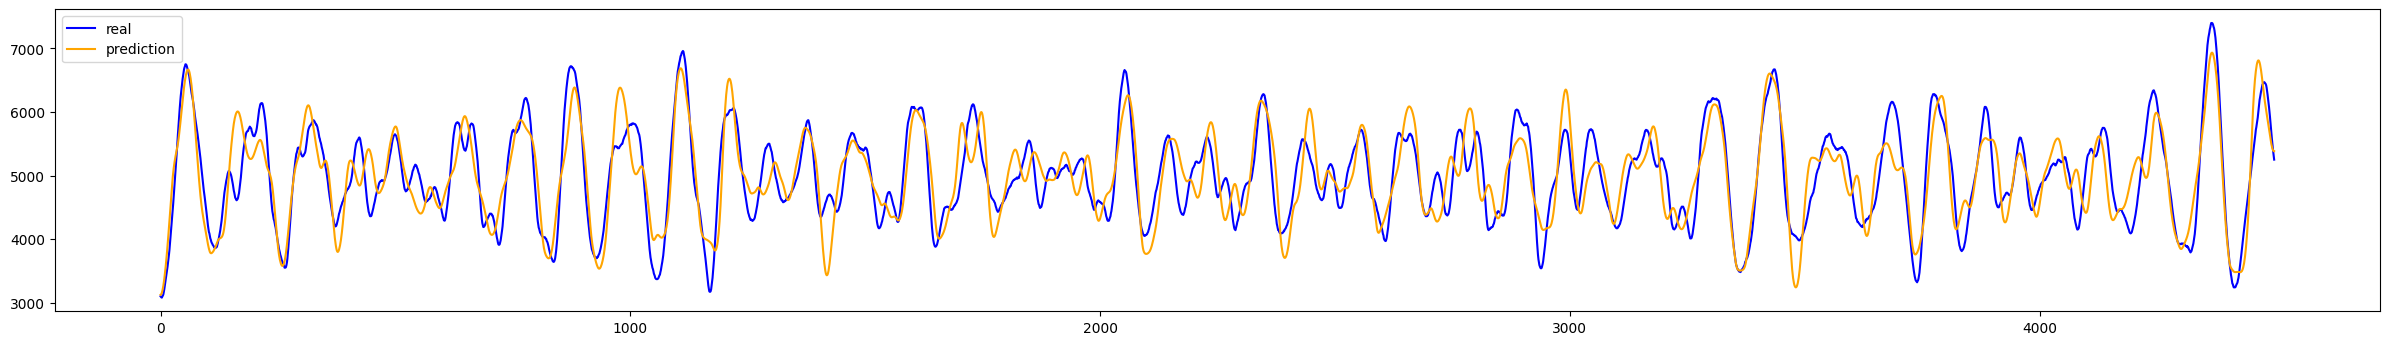

In [21]:
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

np.savetxt('force1500_步长10_混合注意力.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [22]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3500:,:], 4, 509)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [23]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 4500, 7500, 12000)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

In [24]:
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 0s - loss: 0.0500 - val_loss: 0.0489
Epoch 2/1000
 - 0s - loss: 0.0213 - val_loss: 0.0552
Epoch 3/1000
 - 0s - loss: 0.0229 - val_loss: 0.0503
Epoch 4/1000
 - 0s - loss: 0.0164 - val_loss: 0.0486
Epoch 5/1000
 - 0s - loss: 0.0185 - val_loss: 0.0505
Epoch 6/1000
 - 0s - loss: 0.0181 - val_loss: 0.0496
Epoch 7/1000
 - 0s - loss: 0.0177 - val_loss: 0.0496
Epoch 8/1000
 - 0s - loss: 0.0181 - val_loss: 0.0498
Epoch 9/1000
 - 0s - loss: 0.0178 - val_loss: 0.0498
Epoch 10/1000
 - 0s - loss: 0.0179 - val_loss: 0.0498
Epoch 11/1000
 - 0s - loss: 0.0178 - val_loss: 0.0498
Epoch 12/1000
 - 0s - loss: 0.0178 - val_loss: 0.0498
Epoch 13/1000
 - 0s - loss: 0.0178 - val_loss: 0.0498
Epoch 14/1000
 - 0s - loss: 0.0177 - val_loss: 0.0498
Epoch 15/1000
 - 0s - loss: 0.0177 - val_loss: 0.0498
Epoch 16/1000
 - 0s - loss: 0.0176 - val_loss: 0.0498
Epoch 17/1000
 - 0s - loss: 0.0176 - val_loss: 0.0498
Epoch 18/1000
 - 0s - loss: 0.0176 - val_lo

 - 0s - loss: 0.0160 - val_loss: 0.0491
Epoch 152/1000
 - 0s - loss: 0.0160 - val_loss: 0.0491
Epoch 153/1000
 - 0s - loss: 0.0160 - val_loss: 0.0491
Epoch 154/1000
 - 0s - loss: 0.0160 - val_loss: 0.0491
Epoch 155/1000
 - 0s - loss: 0.0160 - val_loss: 0.0491
Epoch 156/1000
 - 0s - loss: 0.0160 - val_loss: 0.0491
Epoch 157/1000
 - 0s - loss: 0.0160 - val_loss: 0.0491
Epoch 158/1000
 - 0s - loss: 0.0160 - val_loss: 0.0491
Epoch 159/1000
 - 0s - loss: 0.0160 - val_loss: 0.0490
Epoch 160/1000
 - 0s - loss: 0.0160 - val_loss: 0.0490
Epoch 161/1000
 - 0s - loss: 0.0159 - val_loss: 0.0490
Epoch 162/1000
 - 0s - loss: 0.0159 - val_loss: 0.0490
Epoch 163/1000
 - 0s - loss: 0.0159 - val_loss: 0.0490
Epoch 164/1000
 - 0s - loss: 0.0159 - val_loss: 0.0490
Epoch 165/1000
 - 0s - loss: 0.0159 - val_loss: 0.0490
Epoch 166/1000
 - 0s - loss: 0.0159 - val_loss: 0.0490
Epoch 167/1000
 - 0s - loss: 0.0159 - val_loss: 0.0490
Epoch 168/1000
 - 0s - loss: 0.0159 - val_loss: 0.0490
Epoch 169/1000
 - 0s - lo

 - 0s - loss: 0.0153 - val_loss: 0.0488
Epoch 301/1000
 - 0s - loss: 0.0152 - val_loss: 0.0487
Epoch 302/1000
 - 0s - loss: 0.0152 - val_loss: 0.0487
Epoch 303/1000
 - 0s - loss: 0.0151 - val_loss: 0.0487
Epoch 304/1000
 - 0s - loss: 0.0151 - val_loss: 0.0487
Epoch 305/1000
 - 0s - loss: 0.0151 - val_loss: 0.0487
Epoch 306/1000
 - 0s - loss: 0.0151 - val_loss: 0.0487
Epoch 307/1000
 - 0s - loss: 0.0150 - val_loss: 0.0487
Epoch 308/1000
 - 0s - loss: 0.0150 - val_loss: 0.0487
Epoch 309/1000
 - 0s - loss: 0.0150 - val_loss: 0.0487
Epoch 310/1000
 - 0s - loss: 0.0150 - val_loss: 0.0486
Epoch 311/1000
 - 0s - loss: 0.0150 - val_loss: 0.0486
Epoch 312/1000
 - 0s - loss: 0.0150 - val_loss: 0.0486
Epoch 313/1000
 - 0s - loss: 0.0150 - val_loss: 0.0486
Epoch 314/1000
 - 0s - loss: 0.0149 - val_loss: 0.0486
Epoch 315/1000
 - 0s - loss: 0.0149 - val_loss: 0.0486
Epoch 316/1000
 - 0s - loss: 0.0149 - val_loss: 0.0486
Epoch 317/1000
 - 0s - loss: 0.0149 - val_loss: 0.0486
Epoch 318/1000
 - 0s - lo

Epoch 450/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 451/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 452/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 453/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 454/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 455/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 456/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 457/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 458/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 459/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 460/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 461/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 462/1000
 - 0s - loss: 0.0147 - val_loss: 0.0488
Epoch 463/1000
 - 0s - loss: 0.0146 - val_loss: 0.0488
Epoch 464/1000
 - 0s - loss: 0.0146 - val_loss: 0.0488
Epoch 465/1000
 - 0s - loss: 0.0146 - val_loss: 0.0488
Epoch 466/1000
 - 0s - loss: 0.0146 - val_loss: 0.0488
Epoch 467/1000
 - 0s - loss: 0.0146 - val_loss: 0.0488
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 600/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 601/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 602/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 603/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 604/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 605/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 606/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 607/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 608/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 609/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 610/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 611/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 612/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 613/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 614/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 615/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 616/1000
 - 0s - loss: 0.0140 - val_loss: 0.0481
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0137 - val_loss: 0.0482
Epoch 749/1000
 - 0s - loss: 0.0137 - val_loss: 0.0483
Epoch 750/1000
 - 0s - loss: 0.0137 - val_loss: 0.0482
Epoch 751/1000
 - 0s - loss: 0.0137 - val_loss: 0.0481
Epoch 752/1000
 - 0s - loss: 0.0137 - val_loss: 0.0481
Epoch 753/1000
 - 0s - loss: 0.0137 - val_loss: 0.0482
Epoch 754/1000
 - 0s - loss: 0.0137 - val_loss: 0.0483
Epoch 755/1000
 - 0s - loss: 0.0138 - val_loss: 0.0483
Epoch 756/1000
 - 0s - loss: 0.0138 - val_loss: 0.0483
Epoch 757/1000
 - 0s - loss: 0.0138 - val_loss: 0.0482
Epoch 758/1000
 - 0s - loss: 0.0138 - val_loss: 0.0481
Epoch 759/1000
 - 0s - loss: 0.0137 - val_loss: 0.0481
Epoch 760/1000
 - 0s - loss: 0.0137 - val_loss: 0.0482
Epoch 761/1000
 - 0s - loss: 0.0137 - val_loss: 0.0483
Epoch 762/1000
 - 0s - loss: 0.0137 - val_loss: 0.0483
Epoch 763/1000
 - 0s - loss: 0.0137 - val_loss: 0.0482
Epoch 764/1000
 - 0s - loss: 0.0137 - val_loss: 0.0481
Epoch 765/1000
 - 0s - loss: 0.0137 - val_loss: 0.0481
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0136 - val_loss: 0.0486
Epoch 898/1000
 - 0s - loss: 0.0136 - val_loss: 0.0485
Epoch 899/1000
 - 0s - loss: 0.0136 - val_loss: 0.0485
Epoch 900/1000
 - 0s - loss: 0.0136 - val_loss: 0.0484
Epoch 901/1000
 - 0s - loss: 0.0136 - val_loss: 0.0485
Epoch 902/1000
 - 0s - loss: 0.0136 - val_loss: 0.0485
Epoch 903/1000
 - 0s - loss: 0.0136 - val_loss: 0.0486
Epoch 904/1000
 - 0s - loss: 0.0136 - val_loss: 0.0486
Epoch 905/1000
 - 0s - loss: 0.0136 - val_loss: 0.0486
Epoch 906/1000
 - 0s - loss: 0.0136 - val_loss: 0.0487
Epoch 907/1000
 - 0s - loss: 0.0136 - val_loss: 0.0487
Epoch 908/1000
 - 0s - loss: 0.0136 - val_loss: 0.0488
Epoch 909/1000
 - 0s - loss: 0.0136 - val_loss: 0.0488
Epoch 910/1000
 - 0s - loss: 0.0136 - val_loss: 0.0487
Epoch 911/1000
 - 0s - loss: 0.0136 - val_loss: 0.0486
Epoch 912/1000
 - 0s - loss: 0.0136 - val_loss: 0.0486
Epoch 913/1000
 - 0s - loss: 0.0136 - val_loss: 0.0485
Epoch 914/1000
 - 0s - loss: 0.0136 - val_loss: 0.0485
Epoch 915/

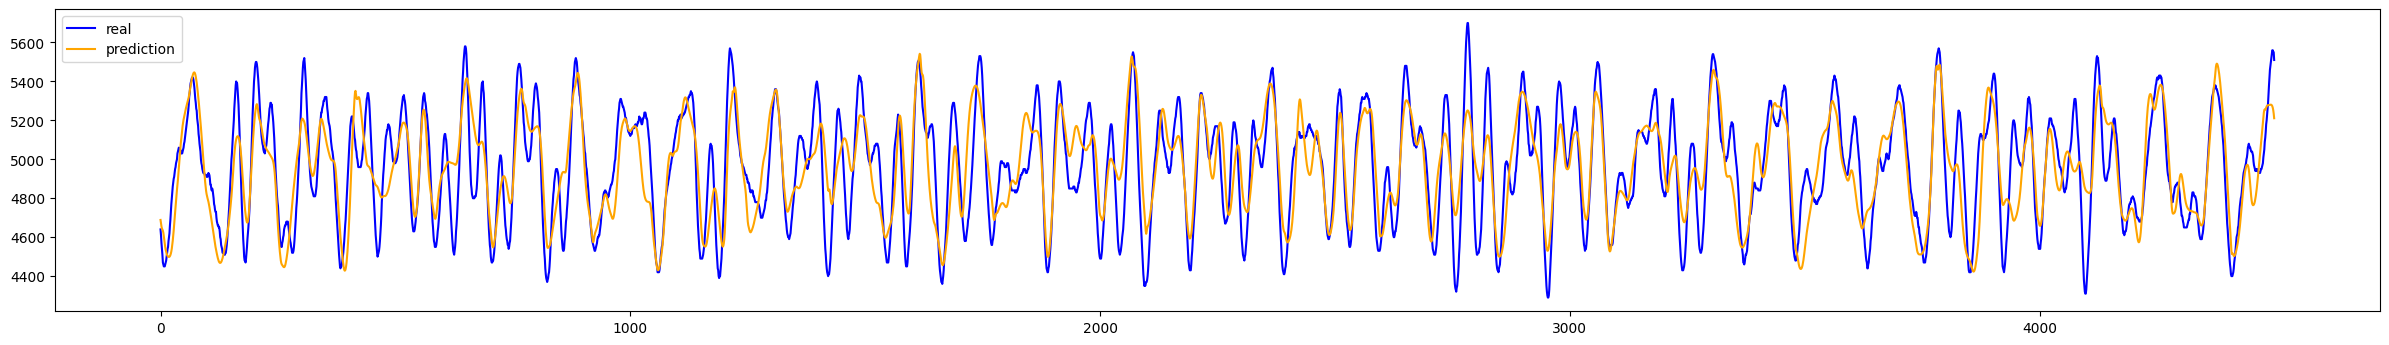

In [25]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force2500_步长10_混合注意力.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

In [26]:
RNSE(valid50_y_Force1,N_pre50_Y_Force1)
Acc(valid50_y_Force1,N_pre50_Y_Force1)

RMSE(sklearn): 0.13643164429394475
Acc: 0.9245357660300162


In [27]:
RNSE(valid50_y_Force2,N_pre50_Y_Force2)
Acc(valid50_y_Force2,N_pre50_Y_Force2)

RMSE(sklearn): 0.22105618158982443
Acc: 0.8501713012001293


#### 系泊缆力联合预测（时间窗500输出；步长20）

In [36]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 4500, 7500, 8000)
heave50_model2, heave50_history2, pre_heave50_Y2 = attention_model(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 4200, 7500, 8000)
surge50_model2, surge50_history2, pre_surge50_Y2 = attention_model(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 4500, 7500, 8000)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = attention_model(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 221s - loss: 0.0848 - val_loss: 0.0565
Epoch 2/30
 - 219s - loss: 0.0437 - val_loss: 0.0337
Epoch 3/30
 - 220s - loss: 0.0297 - val_loss: 0.0364
Epoch 4/30
 - 220s - loss: 0.0264 - val_loss: 0.0306
Epoch 5/30
 - 220s - loss: 0.0226 - val_loss: 0.0228
Epoch 6/30
 - 219s - loss: 0.0195 - val_loss: 0.0238
Epoch 7/30
 - 220s - loss: 0.0166 - val_loss: 0.0274
Epoch 8/30
 - 220s - loss: 0.0172 - val_loss: 0.0276
Epoch 9/30
 - 220s - loss: 0.0194 - val_loss: 0.0304
Epoch 10/30
 - 220s - loss: 0.0203 - val_loss: 0.0174
Epoch 11/30
 - 219s - loss: 0.0131 - val_loss: 0.0382
Epoch 12/30
 - 220s - loss: 0.0181 - val_loss: 0.0208
Epoch 13/30
 - 220s - loss: 0.0132 - val_loss: 0.0375
Epoch 14/30
 - 220s - loss: 0.0146 - val_loss: 0.0171
Epoch 15/30
 - 220s - loss: 0.0119 - val_loss: 0.0349
Epoch 16/30
 - 220s - loss: 0.0102 - val_loss: 0.0226
Epoch 17/30
 - 220s - loss: 0.0103 - val_loss: 0.0193
Epoch 18/30
 - 221s - loss: 0.0130 - val_los

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 231s - loss: 0.0632 - val_loss: 0.0447
Epoch 2/30
 - 230s - loss: 0.0412 - val_loss: 0.0314
Epoch 3/30
 - 230s - loss: 0.0339 - val_loss: 0.0245
Epoch 4/30
 - 230s - loss: 0.0292 - val_loss: 0.0321
Epoch 5/30
 - 231s - loss: 0.0303 - val_loss: 0.0298
Epoch 6/30
 - 231s - loss: 0.0268 - val_loss: 0.0302
Epoch 7/30
 - 231s - loss: 0.0223 - val_loss: 0.0391
Epoch 8/30
 - 231s - loss: 0.0264 - val_loss: 0.0300
Epoch 9/30
 - 230s - loss: 0.0214 - val_loss: 0.0431
Epoch 10/30
 - 231s - loss: 0.0185 - val_loss: 0.0519
Epoch 11/30
 - 230s - loss: 0.0237 - val_loss: 0.0247
Epoch 12/30
 - 230s - loss: 0.0189 - val_loss: 0.0319
Epoch 13/30
 - 230s - loss: 0.0109 - val_loss: 0.0414
Epoch 14/30
 - 232s - loss: 0.0118 - val_loss: 0.0377
Epoch 15/30
 - 231s - loss: 0.0124 - val_loss: 0.0453
Epoch 16/30
 - 231s - loss: 0.0140 - val_loss: 0.0444
Epoch 17/30
 - 231s - loss: 0.0147 - val_loss: 0.0580
Epoch 18/30
 - 231s - loss: 0.0173 - val_los

In [105]:
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 4500, 7500, 12000)
train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 4200, 7500, 12000)                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 4500, 7500, 12000)

In [106]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [107]:
pre_heave50_Y2 = heave50_model2.predict(valid_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y2 = surge50_model2.predict(valid_surge50_x2)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y2 = pitch50_model2.predict(valid_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pre_heave50_Y2.shape)
print(pre_surge50_Y2.shape)
print(pre_pitch50_Y2.shape)

(4500, 1)
(4500, 1)
(4500, 1)


In [108]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
# print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [109]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 4500, 7500, 12000)
train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2

In [110]:
N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 1s - loss: 0.0255 - val_loss: 0.0190
Epoch 2/1000
 - 1s - loss: 0.0066 - val_loss: 0.0210
Epoch 3/1000
 - 1s - loss: 0.0029 - val_loss: 0.0205
Epoch 4/1000
 - 1s - loss: 0.0048 - val_loss: 0.0191
Epoch 5/1000
 - 1s - loss: 0.0022 - val_loss: 0.0199
Epoch 6/1000
 - 1s - loss: 0.0033 - val_loss: 0.0186
Epoch 7/1000
 - 1s - loss: 0.0025 - val_loss: 0.0194
Epoch 8/1000
 - 1s - loss: 0.0031 - val_loss: 0.0189
Epoch 9/1000
 - 1s - loss: 0.0028 - val_loss: 0.0190
Epoch 10/1000
 - 1s - loss: 0.0029 - val_loss: 0.0189
Epoch 11/1000
 - 1s - loss: 0.0029 - val_loss: 0.0190
Epoch 12/1000
 - 1s - loss: 0.0029 - val_loss: 0.0190
Epoch 13/1000
 - 1s - loss: 0.0030 - val_loss: 0.0189
Epoch 14/1000
 - 1s - loss: 0.0030 - val_loss: 0.0189
Epoch 15/1000
 - 1s - loss: 0.0030 - val_loss: 0.0189
Epoch 16/1000
 - 1s - loss: 0.0029 - val_loss: 0.0189
Epoch 17/1000
 - 1s - loss: 0.0029 - val_loss: 0.0189
Epoch 18/1000
 - 1s - loss: 0.0029 - val_lo

 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 152/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 153/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 154/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 155/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 156/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 157/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 158/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 159/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 160/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 161/1000
 - 1s - loss: 0.0023 - val_loss: 0.0191
Epoch 162/1000
 - 1s - loss: 0.0023 - val_loss: 0.0191
Epoch 163/1000
 - 1s - loss: 0.0023 - val_loss: 0.0191
Epoch 164/1000
 - 1s - loss: 0.0023 - val_loss: 0.0191
Epoch 165/1000
 - 1s - loss: 0.0023 - val_loss: 0.0191
Epoch 166/1000
 - 1s - loss: 0.0023 - val_loss: 0.0191
Epoch 167/1000
 - 1s - loss: 0.0023 - val_loss: 0.0191
Epoch 168/1000
 - 1s - loss: 0.0023 - val_loss: 0.0191
Epoch 169/1000
 - 1s - lo

 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 301/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 302/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 303/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 304/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 305/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 306/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 307/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 308/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 309/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 310/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 311/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 312/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 313/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 314/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 315/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 316/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 317/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 318/1000
 - 1s - lo

 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 450/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 451/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 452/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 453/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 454/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 455/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 456/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 457/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 458/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 459/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 460/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 461/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 462/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 463/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 464/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 465/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 466/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 467/1000
 - 1s - lo

 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 599/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 600/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 601/1000
 - 1s - loss: 0.0022 - val_loss: 0.0193
Epoch 602/1000
 - 1s - loss: 0.0022 - val_loss: 0.0193
Epoch 603/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 604/1000
 - 1s - loss: 0.0022 - val_loss: 0.0193
Epoch 605/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 606/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 607/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 608/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 609/1000
 - 1s - loss: 0.0021 - val_loss: 0.0194
Epoch 610/1000
 - 1s - loss: 0.0022 - val_loss: 0.0192
Epoch 611/1000
 - 1s - loss: 0.0022 - val_loss: 0.0190
Epoch 612/1000
 - 1s - loss: 0.0022 - val_loss: 0.0194
Epoch 613/1000
 - 1s - loss: 0.0022 - val_loss: 0.0197
Epoch 614/1000
 - 1s - loss: 0.0024 - val_loss: 0.0191
Epoch 615/1000
 - 1s - loss: 0.0026 - val_loss: 0.0193
Epoch 616/1000
 - 1s - lo

 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 748/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 749/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 750/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 751/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 752/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 753/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 754/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 755/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 756/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 757/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 758/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 759/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 760/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 761/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 762/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 763/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 764/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 765/1000
 - 1s - lo

 - 1s - loss: 0.0021 - val_loss: 0.0192
Epoch 897/1000
 - 1s - loss: 0.0020 - val_loss: 0.0194
Epoch 898/1000
 - 1s - loss: 0.0021 - val_loss: 0.0196
Epoch 899/1000
 - 1s - loss: 0.0021 - val_loss: 0.0195
Epoch 900/1000
 - 1s - loss: 0.0021 - val_loss: 0.0192
Epoch 901/1000
 - 1s - loss: 0.0020 - val_loss: 0.0193
Epoch 902/1000
 - 1s - loss: 0.0021 - val_loss: 0.0196
Epoch 903/1000
 - 1s - loss: 0.0021 - val_loss: 0.0195
Epoch 904/1000
 - 1s - loss: 0.0021 - val_loss: 0.0192
Epoch 905/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 906/1000
 - 1s - loss: 0.0021 - val_loss: 0.0196
Epoch 907/1000
 - 1s - loss: 0.0021 - val_loss: 0.0195
Epoch 908/1000
 - 1s - loss: 0.0021 - val_loss: 0.0192
Epoch 909/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 910/1000
 - 1s - loss: 0.0020 - val_loss: 0.0196
Epoch 911/1000
 - 1s - loss: 0.0021 - val_loss: 0.0195
Epoch 912/1000
 - 1s - loss: 0.0021 - val_loss: 0.0192
Epoch 913/1000
 - 1s - loss: 0.0021 - val_loss: 0.0193
Epoch 914/1000
 - 1s - lo

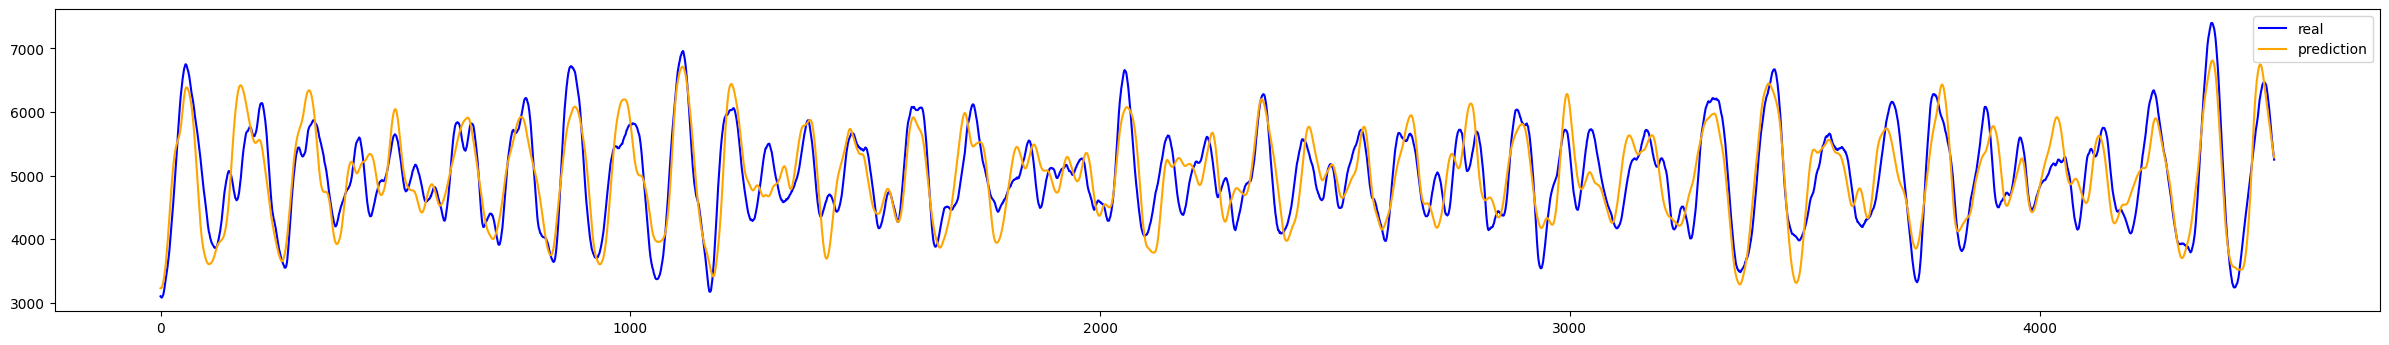

In [111]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force1500_步长20_混合注意力.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')

In [112]:
# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3490:,:], 4, 519)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [113]:
train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 4500, 7500, 12000)
train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2

In [114]:
N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 1s - loss: 0.0628 - val_loss: 0.1001
Epoch 2/1000
 - 1s - loss: 0.0334 - val_loss: 0.1070
Epoch 3/1000
 - 1s - loss: 0.0297 - val_loss: 0.1031
Epoch 4/1000
 - 1s - loss: 0.0245 - val_loss: 0.1009
Epoch 5/1000
 - 1s - loss: 0.0244 - val_loss: 0.1021
Epoch 6/1000
 - 1s - loss: 0.0246 - val_loss: 0.1025
Epoch 7/1000
 - 1s - loss: 0.0246 - val_loss: 0.1016
Epoch 8/1000
 - 1s - loss: 0.0242 - val_loss: 0.1019
Epoch 9/1000
 - 1s - loss: 0.0245 - val_loss: 0.1015
Epoch 10/1000
 - 1s - loss: 0.0245 - val_loss: 0.1017
Epoch 11/1000
 - 1s - loss: 0.0244 - val_loss: 0.1013
Epoch 12/1000
 - 1s - loss: 0.0245 - val_loss: 0.1016
Epoch 13/1000
 - 1s - loss: 0.0244 - val_loss: 0.1014
Epoch 14/1000
 - 1s - loss: 0.0244 - val_loss: 0.1015
Epoch 15/1000
 - 1s - loss: 0.0243 - val_loss: 0.1014
Epoch 16/1000
 - 1s - loss: 0.0243 - val_loss: 0.1015
Epoch 17/1000
 - 1s - loss: 0.0243 - val_loss: 0.1014
Epoch 18/1000
 - 1s - loss: 0.0242 - val_lo

 - 1s - loss: 0.0218 - val_loss: 0.1034
Epoch 152/1000
 - 1s - loss: 0.0218 - val_loss: 0.1034
Epoch 153/1000
 - 1s - loss: 0.0218 - val_loss: 0.1034
Epoch 154/1000
 - 1s - loss: 0.0218 - val_loss: 0.1035
Epoch 155/1000
 - 1s - loss: 0.0218 - val_loss: 0.1035
Epoch 156/1000
 - 1s - loss: 0.0217 - val_loss: 0.1035
Epoch 157/1000
 - 1s - loss: 0.0217 - val_loss: 0.1036
Epoch 158/1000
 - 1s - loss: 0.0217 - val_loss: 0.1036
Epoch 159/1000
 - 1s - loss: 0.0217 - val_loss: 0.1036
Epoch 160/1000
 - 1s - loss: 0.0217 - val_loss: 0.1036
Epoch 161/1000
 - 1s - loss: 0.0217 - val_loss: 0.1036
Epoch 162/1000
 - 1s - loss: 0.0217 - val_loss: 0.1037
Epoch 163/1000
 - 1s - loss: 0.0217 - val_loss: 0.1037
Epoch 164/1000
 - 1s - loss: 0.0217 - val_loss: 0.1037
Epoch 165/1000
 - 1s - loss: 0.0217 - val_loss: 0.1037
Epoch 166/1000
 - 1s - loss: 0.0216 - val_loss: 0.1037
Epoch 167/1000
 - 1s - loss: 0.0216 - val_loss: 0.1038
Epoch 168/1000
 - 1s - loss: 0.0216 - val_loss: 0.1038
Epoch 169/1000
 - 1s - lo

 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 301/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 302/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 303/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 304/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 305/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 306/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 307/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 308/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 309/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 310/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 311/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 312/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 313/1000
 - 1s - loss: 0.0209 - val_loss: 0.1046
Epoch 314/1000
 - 1s - loss: 0.0209 - val_loss: 0.1047
Epoch 315/1000
 - 1s - loss: 0.0209 - val_loss: 0.1047
Epoch 316/1000
 - 1s - loss: 0.0209 - val_loss: 0.1047
Epoch 317/1000
 - 1s - loss: 0.0209 - val_loss: 0.1047
Epoch 318/1000
 - 1s - lo

 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 450/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 451/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 452/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 453/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 454/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 455/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 456/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 457/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 458/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 459/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 460/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 461/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 462/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 463/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 464/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 465/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 466/1000
 - 1s - loss: 0.0207 - val_loss: 0.1051
Epoch 467/1000
 - 1s - lo

 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 599/1000
 - 1s - loss: 0.0205 - val_loss: 0.1053
Epoch 600/1000
 - 1s - loss: 0.0205 - val_loss: 0.1053
Epoch 601/1000
 - 1s - loss: 0.0205 - val_loss: 0.1053
Epoch 602/1000
 - 1s - loss: 0.0205 - val_loss: 0.1053
Epoch 603/1000
 - 1s - loss: 0.0205 - val_loss: 0.1053
Epoch 604/1000
 - 1s - loss: 0.0205 - val_loss: 0.1053
Epoch 605/1000
 - 1s - loss: 0.0205 - val_loss: 0.1053
Epoch 606/1000
 - 1s - loss: 0.0205 - val_loss: 0.1053
Epoch 607/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 608/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 609/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 610/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 611/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 612/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 613/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 614/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 615/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 616/1000
 - 1s - lo

 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 748/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 749/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 750/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 751/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 752/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 753/1000
 - 1s - loss: 0.0205 - val_loss: 0.1054
Epoch 754/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 755/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 756/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 757/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 758/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 759/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 760/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 761/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 762/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 763/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 764/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 765/1000
 - 1s - lo

 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 897/1000
 - 1s - loss: 0.0204 - val_loss: 0.1056
Epoch 898/1000
 - 1s - loss: 0.0204 - val_loss: 0.1056
Epoch 899/1000
 - 1s - loss: 0.0204 - val_loss: 0.1056
Epoch 900/1000
 - 1s - loss: 0.0204 - val_loss: 0.1056
Epoch 901/1000
 - 1s - loss: 0.0204 - val_loss: 0.1056
Epoch 902/1000
 - 1s - loss: 0.0204 - val_loss: 0.1056
Epoch 903/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 904/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 905/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 906/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 907/1000
 - 1s - loss: 0.0205 - val_loss: 0.1055
Epoch 908/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 909/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 910/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 911/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 912/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 913/1000
 - 1s - loss: 0.0204 - val_loss: 0.1055
Epoch 914/1000
 - 1s - lo

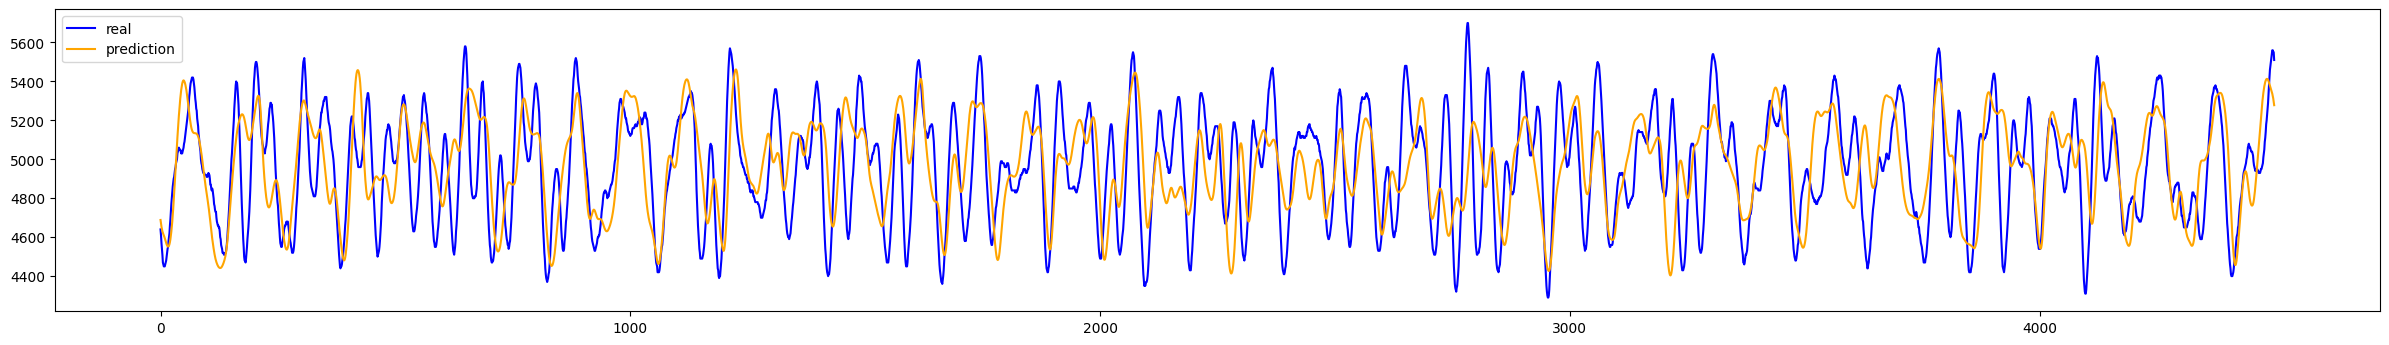

In [115]:
fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force2500_步长20_混合注意力.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

In [116]:
RNSE(valid50_y2_Force1,N_pre50_Y2_Force1)
Acc(valid50_y2_Force1,N_pre50_Y2_Force1)

RMSE(sklearn): 0.13906083613801717
Acc: 0.9583644025256444


In [117]:
RNSE(valid50_y2_Force2,N_pre50_Y2_Force2)
Acc(valid50_y2_Force2,N_pre50_Y2_Force2)

RMSE(sklearn): 0.32490291968637763
Acc: 0.8293849061119716


#### 系泊缆力联合预测（时间窗500输出；步长30）

In [48]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 4500, 7500, 8000)
heave50_model3, heave50_history3, pre_heave50_Y3 = attention_model(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 4200, 7500, 8000)
surge50_model3, surge50_history3, pre_surge50_Y3 = attention_model(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 4500, 7500, 8000)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = attention_model(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 223s - loss: 0.0861 - val_loss: 0.0664
Epoch 2/30
 - 224s - loss: 0.0450 - val_loss: 0.0477
Epoch 3/30
 - 221s - loss: 0.0339 - val_loss: 0.0328
Epoch 4/30
 - 222s - loss: 0.0283 - val_loss: 0.0387
Epoch 5/30
 - 222s - loss: 0.0268 - val_loss: 0.0331
Epoch 6/30
 - 221s - loss: 0.0220 - val_loss: 0.0316
Epoch 7/30
 - 221s - loss: 0.0205 - val_loss: 0.0326
Epoch 8/30
 - 221s - loss: 0.0196 - val_loss: 0.0199
Epoch 9/30
 - 221s - loss: 0.0179 - val_loss: 0.0290
Epoch 10/30
 - 221s - loss: 0.0172 - val_loss: 0.0176
Epoch 11/30
 - 221s - loss: 0.0119 - val_loss: 0.0280
Epoch 12/30
 - 221s - loss: 0.0148 - val_loss: 0.0265
Epoch 13/30
 - 221s - loss: 0.0132 - val_loss: 0.0306
Epoch 14/30
 - 221s - loss: 0.0206 - val_loss: 0.0295
Epoch 15/30
 - 221s - loss: 0.0157 - val_loss: 0.0235
Epoch 16/30
 - 222s - loss: 0.0095 - val_loss: 0.0397
Epoch 17/30
 - 222s - loss: 0.0128 - val_loss: 0.0191
Epoch 18/30
 - 222s - loss: 0.0095 - val_los

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 241s - loss: 0.0715 - val_loss: 0.0625
Epoch 2/30
 - 237s - loss: 0.0617 - val_loss: 0.0532
Epoch 3/30
 - 238s - loss: 0.0543 - val_loss: 0.0439
Epoch 4/30
 - 235s - loss: 0.0505 - val_loss: 0.0408
Epoch 5/30
 - 236s - loss: 0.0410 - val_loss: 0.0532
Epoch 6/30
 - 236s - loss: 0.0416 - val_loss: 0.0781
Epoch 7/30
 - 237s - loss: 0.0413 - val_loss: 0.0401
Epoch 8/30
 - 237s - loss: 0.0434 - val_loss: 0.0493
Epoch 9/30
 - 235s - loss: 0.0298 - val_loss: 0.0491
Epoch 10/30
 - 234s - loss: 0.0314 - val_loss: 0.0701
Epoch 11/30
 - 235s - loss: 0.0392 - val_loss: 0.0633
Epoch 12/30
 - 235s - loss: 0.0283 - val_loss: 0.0624
Epoch 13/30
 - 237s - loss: 0.0193 - val_loss: 0.0674
Epoch 14/30
 - 236s - loss: 0.0177 - val_loss: 0.0684
Epoch 15/30
 - 237s - loss: 0.0173 - val_loss: 0.0667
Epoch 16/30
 - 237s - loss: 0.0132 - val_loss: 0.0571
Epoch 17/30
 - 238s - loss: 0.0106 - val_loss: 0.0709
Epoch 18/30
 - 237s - loss: 0.0122 - val_los

In [92]:
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 4500, 7500, 12000)
train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 4200, 7500, 12000)                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 4500, 7500, 12000)

In [93]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [94]:
pre_heave50_Y3 = heave50_model3.predict(valid_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y3 = surge50_model3.predict(valid_surge50_x3)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y3 = pitch50_model3.predict(valid_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
# print(pre_heave50_Y3.shape)
# print(pre_surge50_Y3.shape)
# print(pre_pitch50_Y3.shape)

In [95]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [96]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 4500, 7500, 12000)
train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3

In [97]:
N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 1s - loss: 0.0231 - val_loss: 0.0263
Epoch 2/1000
 - 1s - loss: 0.0040 - val_loss: 0.0202
Epoch 3/1000
 - 1s - loss: 0.0029 - val_loss: 0.0202
Epoch 4/1000
 - 1s - loss: 0.0030 - val_loss: 0.0197
Epoch 5/1000
 - 1s - loss: 0.0026 - val_loss: 0.0195
Epoch 6/1000
 - 1s - loss: 0.0028 - val_loss: 0.0197
Epoch 7/1000
 - 1s - loss: 0.0027 - val_loss: 0.0197
Epoch 8/1000
 - 1s - loss: 0.0028 - val_loss: 0.0197
Epoch 9/1000
 - 1s - loss: 0.0028 - val_loss: 0.0198
Epoch 10/1000
 - 1s - loss: 0.0028 - val_loss: 0.0198
Epoch 11/1000
 - 1s - loss: 0.0029 - val_loss: 0.0199
Epoch 12/1000
 - 1s - loss: 0.0029 - val_loss: 0.0199
Epoch 13/1000
 - 1s - loss: 0.0029 - val_loss: 0.0199
Epoch 14/1000
 - 1s - loss: 0.0029 - val_loss: 0.0199
Epoch 15/1000
 - 1s - loss: 0.0029 - val_loss: 0.0199
Epoch 16/1000
 - 1s - loss: 0.0028 - val_loss: 0.0199
Epoch 17/1000
 - 1s - loss: 0.0028 - val_loss: 0.0198
Epoch 18/1000
 - 1s - loss: 0.0028 - val_lo

 - 1s - loss: 0.0021 - val_loss: 0.0198
Epoch 152/1000
 - 1s - loss: 0.0021 - val_loss: 0.0199
Epoch 153/1000
 - 1s - loss: 0.0020 - val_loss: 0.0200
Epoch 154/1000
 - 1s - loss: 0.0020 - val_loss: 0.0201
Epoch 155/1000
 - 1s - loss: 0.0020 - val_loss: 0.0201
Epoch 156/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 157/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 158/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 159/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 160/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 161/1000
 - 1s - loss: 0.0020 - val_loss: 0.0204
Epoch 162/1000
 - 1s - loss: 0.0020 - val_loss: 0.0204
Epoch 163/1000
 - 1s - loss: 0.0021 - val_loss: 0.0205
Epoch 164/1000
 - 1s - loss: 0.0021 - val_loss: 0.0205
Epoch 165/1000
 - 1s - loss: 0.0021 - val_loss: 0.0206
Epoch 166/1000
 - 1s - loss: 0.0021 - val_loss: 0.0207
Epoch 167/1000
 - 1s - loss: 0.0021 - val_loss: 0.0208
Epoch 168/1000
 - 1s - loss: 0.0021 - val_loss: 0.0208
Epoch 169/1000
 - 1s - lo

 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 301/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 302/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 303/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 304/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 305/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 306/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 307/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 308/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 309/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 310/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 311/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 312/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 313/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 314/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 315/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 316/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 317/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 318/1000
 - 1s - lo

 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 450/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 451/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 452/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 453/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 454/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 455/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 456/1000
 - 1s - loss: 0.0020 - val_loss: 0.0202
Epoch 457/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 458/1000
 - 1s - loss: 0.0020 - val_loss: 0.0203
Epoch 459/1000
 - 1s - loss: 0.0020 - val_loss: 0.0204
Epoch 460/1000
 - 1s - loss: 0.0020 - val_loss: 0.0204
Epoch 461/1000
 - 1s - loss: 0.0020 - val_loss: 0.0206
Epoch 462/1000
 - 1s - loss: 0.0021 - val_loss: 0.0211
Epoch 463/1000
 - 1s - loss: 0.0022 - val_loss: 0.0216
Epoch 464/1000
 - 1s - loss: 0.0024 - val_loss: 0.0214
Epoch 465/1000
 - 1s - loss: 0.0025 - val_loss: 0.0218
Epoch 466/1000
 - 1s - loss: 0.0028 - val_loss: 0.0211
Epoch 467/1000
 - 1s - lo

 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 599/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 600/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 601/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 602/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 603/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 604/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 605/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 606/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 607/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 608/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 609/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 610/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 611/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 612/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 613/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 614/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 615/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 616/1000
 - 1s - lo

 - 1s - loss: 0.0020 - val_loss: 0.0207
Epoch 748/1000
 - 1s - loss: 0.0021 - val_loss: 0.0215
Epoch 749/1000
 - 1s - loss: 0.0023 - val_loss: 0.0215
Epoch 750/1000
 - 1s - loss: 0.0025 - val_loss: 0.0235
Epoch 751/1000
 - 1s - loss: 0.0027 - val_loss: 0.0208
Epoch 752/1000
 - 1s - loss: 0.0026 - val_loss: 0.0216
Epoch 753/1000
 - 1s - loss: 0.0024 - val_loss: 0.0221
Epoch 754/1000
 - 1s - loss: 0.0025 - val_loss: 0.0224
Epoch 755/1000
 - 1s - loss: 0.0027 - val_loss: 0.0223
Epoch 756/1000
 - 1s - loss: 0.0026 - val_loss: 0.0237
Epoch 757/1000
 - 1s - loss: 0.0031 - val_loss: 0.0233
Epoch 758/1000
 - 1s - loss: 0.0030 - val_loss: 0.0240
Epoch 759/1000
 - 1s - loss: 0.0031 - val_loss: 0.0224
Epoch 760/1000
 - 1s - loss: 0.0031 - val_loss: 0.0208
Epoch 761/1000
 - 1s - loss: 0.0028 - val_loss: 0.0200
Epoch 762/1000
 - 1s - loss: 0.0024 - val_loss: 0.0197
Epoch 763/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 764/1000
 - 1s - loss: 0.0019 - val_loss: 0.0200
Epoch 765/1000
 - 1s - lo

 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 897/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 898/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 899/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 900/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 901/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 902/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 903/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 904/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 905/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 906/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 907/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 908/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 909/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 910/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 911/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 912/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 913/1000
 - 1s - loss: 0.0019 - val_loss: 0.0201
Epoch 914/1000
 - 1s - lo

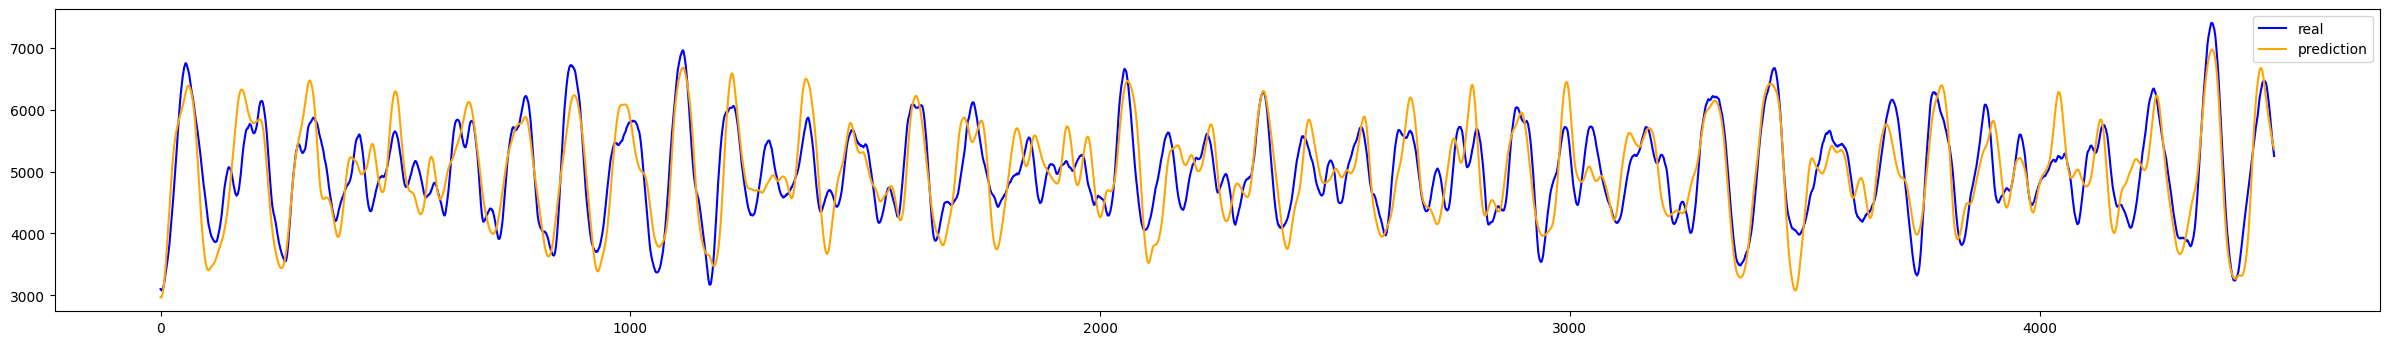

In [98]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force1500_步长30_混合注意力.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')

In [99]:
# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3480:,:], 4, 529)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [100]:
train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 4500, 7500, 12000)
train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3

In [101]:
N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 1s - loss: 0.0588 - val_loss: 0.1001
Epoch 2/1000
 - 1s - loss: 0.0341 - val_loss: 0.1235
Epoch 3/1000
 - 1s - loss: 0.0263 - val_loss: 0.1124
Epoch 4/1000
 - 1s - loss: 0.0233 - val_loss: 0.1144
Epoch 5/1000
 - 1s - loss: 0.0259 - val_loss: 0.1135
Epoch 6/1000
 - 1s - loss: 0.0233 - val_loss: 0.1147
Epoch 7/1000
 - 1s - loss: 0.0255 - val_loss: 0.1133
Epoch 8/1000
 - 1s - loss: 0.0236 - val_loss: 0.1147
Epoch 9/1000
 - 1s - loss: 0.0248 - val_loss: 0.1134
Epoch 10/1000
 - 1s - loss: 0.0237 - val_loss: 0.1146
Epoch 11/1000
 - 1s - loss: 0.0243 - val_loss: 0.1137
Epoch 12/1000
 - 1s - loss: 0.0236 - val_loss: 0.1145
Epoch 13/1000
 - 1s - loss: 0.0240 - val_loss: 0.1139
Epoch 14/1000
 - 1s - loss: 0.0236 - val_loss: 0.1144
Epoch 15/1000
 - 1s - loss: 0.0238 - val_loss: 0.1140
Epoch 16/1000
 - 1s - loss: 0.0235 - val_loss: 0.1144
Epoch 17/1000
 - 1s - loss: 0.0236 - val_loss: 0.1141
Epoch 18/1000
 - 1s - loss: 0.0234 - val_lo

 - 1s - loss: 0.0195 - val_loss: 0.1140
Epoch 152/1000
 - 1s - loss: 0.0195 - val_loss: 0.1140
Epoch 153/1000
 - 1s - loss: 0.0195 - val_loss: 0.1140
Epoch 154/1000
 - 1s - loss: 0.0195 - val_loss: 0.1141
Epoch 155/1000
 - 1s - loss: 0.0195 - val_loss: 0.1140
Epoch 156/1000
 - 1s - loss: 0.0195 - val_loss: 0.1141
Epoch 157/1000
 - 1s - loss: 0.0195 - val_loss: 0.1141
Epoch 158/1000
 - 1s - loss: 0.0195 - val_loss: 0.1141
Epoch 159/1000
 - 1s - loss: 0.0195 - val_loss: 0.1141
Epoch 160/1000
 - 1s - loss: 0.0195 - val_loss: 0.1141
Epoch 161/1000
 - 1s - loss: 0.0194 - val_loss: 0.1141
Epoch 162/1000
 - 1s - loss: 0.0194 - val_loss: 0.1141
Epoch 163/1000
 - 1s - loss: 0.0194 - val_loss: 0.1141
Epoch 164/1000
 - 1s - loss: 0.0194 - val_loss: 0.1141
Epoch 165/1000
 - 1s - loss: 0.0194 - val_loss: 0.1141
Epoch 166/1000
 - 1s - loss: 0.0194 - val_loss: 0.1142
Epoch 167/1000
 - 1s - loss: 0.0194 - val_loss: 0.1142
Epoch 168/1000
 - 1s - loss: 0.0194 - val_loss: 0.1142
Epoch 169/1000
 - 1s - lo

 - 1s - loss: 0.0185 - val_loss: 0.1166
Epoch 301/1000
 - 1s - loss: 0.0186 - val_loss: 0.1166
Epoch 302/1000
 - 1s - loss: 0.0186 - val_loss: 0.1163
Epoch 303/1000
 - 1s - loss: 0.0185 - val_loss: 0.1160
Epoch 304/1000
 - 1s - loss: 0.0185 - val_loss: 0.1158
Epoch 305/1000
 - 1s - loss: 0.0184 - val_loss: 0.1157
Epoch 306/1000
 - 1s - loss: 0.0184 - val_loss: 0.1156
Epoch 307/1000
 - 1s - loss: 0.0185 - val_loss: 0.1156
Epoch 308/1000
 - 1s - loss: 0.0185 - val_loss: 0.1157
Epoch 309/1000
 - 1s - loss: 0.0185 - val_loss: 0.1161
Epoch 310/1000
 - 1s - loss: 0.0185 - val_loss: 0.1165
Epoch 311/1000
 - 1s - loss: 0.0185 - val_loss: 0.1166
Epoch 312/1000
 - 1s - loss: 0.0185 - val_loss: 0.1165
Epoch 313/1000
 - 1s - loss: 0.0185 - val_loss: 0.1163
Epoch 314/1000
 - 1s - loss: 0.0185 - val_loss: 0.1160
Epoch 315/1000
 - 1s - loss: 0.0184 - val_loss: 0.1158
Epoch 316/1000
 - 1s - loss: 0.0184 - val_loss: 0.1157
Epoch 317/1000
 - 1s - loss: 0.0184 - val_loss: 0.1156
Epoch 318/1000
 - 1s - lo

 - 1s - loss: 0.0181 - val_loss: 0.1165
Epoch 450/1000
 - 1s - loss: 0.0181 - val_loss: 0.1165
Epoch 451/1000
 - 1s - loss: 0.0181 - val_loss: 0.1164
Epoch 452/1000
 - 1s - loss: 0.0181 - val_loss: 0.1164
Epoch 453/1000
 - 1s - loss: 0.0181 - val_loss: 0.1163
Epoch 454/1000
 - 1s - loss: 0.0181 - val_loss: 0.1163
Epoch 455/1000
 - 1s - loss: 0.0181 - val_loss: 0.1163
Epoch 456/1000
 - 1s - loss: 0.0181 - val_loss: 0.1163
Epoch 457/1000
 - 1s - loss: 0.0181 - val_loss: 0.1164
Epoch 458/1000
 - 1s - loss: 0.0181 - val_loss: 0.1164
Epoch 459/1000
 - 1s - loss: 0.0181 - val_loss: 0.1165
Epoch 460/1000
 - 1s - loss: 0.0181 - val_loss: 0.1165
Epoch 461/1000
 - 1s - loss: 0.0181 - val_loss: 0.1165
Epoch 462/1000
 - 1s - loss: 0.0181 - val_loss: 0.1165
Epoch 463/1000
 - 1s - loss: 0.0181 - val_loss: 0.1165
Epoch 464/1000
 - 1s - loss: 0.0181 - val_loss: 0.1164
Epoch 465/1000
 - 1s - loss: 0.0181 - val_loss: 0.1164
Epoch 466/1000
 - 1s - loss: 0.0181 - val_loss: 0.1164
Epoch 467/1000
 - 1s - lo

 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 599/1000
 - 1s - loss: 0.0179 - val_loss: 0.1166
Epoch 600/1000
 - 1s - loss: 0.0179 - val_loss: 0.1166
Epoch 601/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 602/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 603/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 604/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 605/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 606/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 607/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 608/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 609/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 610/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 611/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 612/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 613/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 614/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 615/1000
 - 1s - loss: 0.0179 - val_loss: 0.1167
Epoch 616/1000
 - 1s - lo

 - 1s - loss: 0.0178 - val_loss: 0.1169
Epoch 748/1000
 - 1s - loss: 0.0178 - val_loss: 0.1170
Epoch 749/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 750/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 751/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 752/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 753/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 754/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 755/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 756/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 757/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 758/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 759/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 760/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 761/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 762/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 763/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 764/1000
 - 1s - loss: 0.0177 - val_loss: 0.1170
Epoch 765/1000
 - 1s - lo

 - 1s - loss: 0.0175 - val_loss: 0.1171
Epoch 897/1000
 - 1s - loss: 0.0175 - val_loss: 0.1171
Epoch 898/1000
 - 1s - loss: 0.0175 - val_loss: 0.1171
Epoch 899/1000
 - 1s - loss: 0.0175 - val_loss: 0.1171
Epoch 900/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 901/1000
 - 1s - loss: 0.0175 - val_loss: 0.1171
Epoch 902/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 903/1000
 - 1s - loss: 0.0175 - val_loss: 0.1171
Epoch 904/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 905/1000
 - 1s - loss: 0.0175 - val_loss: 0.1171
Epoch 906/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 907/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 908/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 909/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 910/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 911/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 912/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 913/1000
 - 1s - loss: 0.0175 - val_loss: 0.1172
Epoch 914/1000
 - 1s - lo

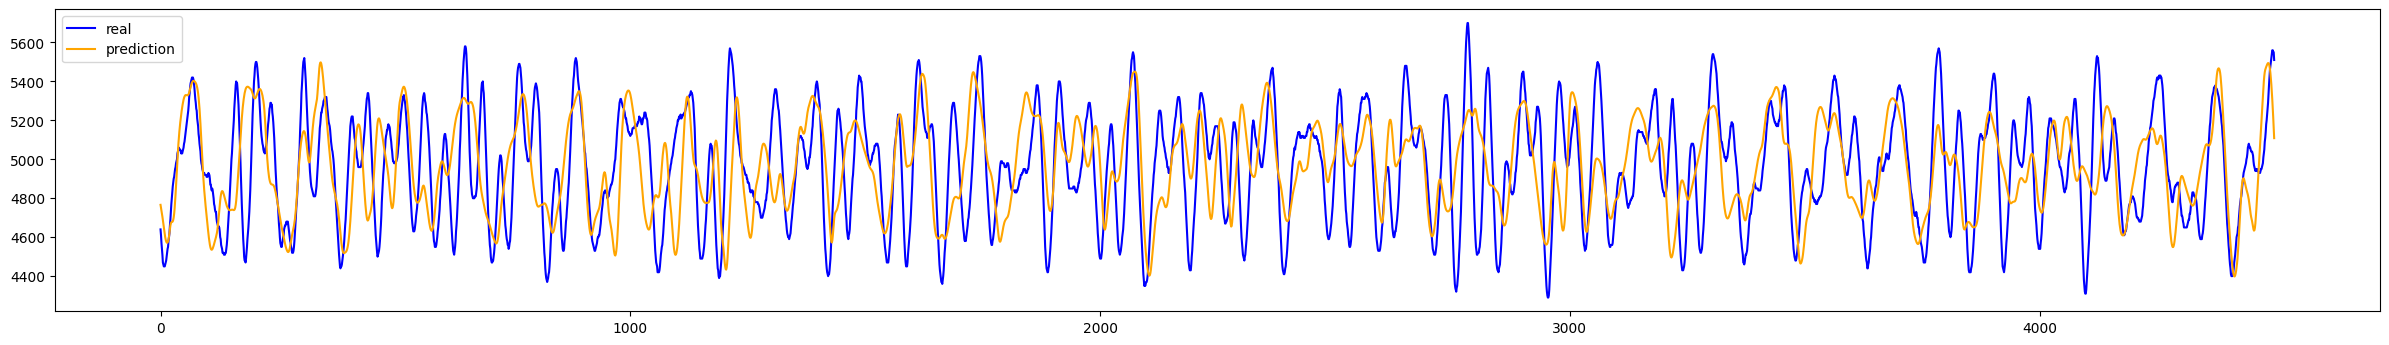

In [102]:
fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force2500_步长30_混合注意力.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

In [103]:
RNSE(valid50_y3_Force1,N_pre50_Y3_Force1)
Acc(valid50_y3_Force1,N_pre50_Y3_Force1)

RMSE(sklearn): 0.1481368192739253
Acc: 0.9598491768203705


In [104]:
RNSE(valid50_y3_Force2,N_pre50_Y3_Force2)
Acc(valid50_y3_Force2,N_pre50_Y3_Force2)

RMSE(sklearn): 0.34328132669817674
Acc: 0.8244388814691554


#### 系泊缆力联合预测（时间窗500输出；步长40）

In [60]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 4500, 7500, 8000)
heave50_model4, heave50_history4, pre_heave50_Y4 = attention_model(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 4200, 7500, 8000)
surge50_model4, surge50_history4, pre_surge50_Y4 = attention_model(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 4500, 7500, 8000)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = attention_model(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 249s - loss: 0.0850 - val_loss: 0.0561
Epoch 2/30
 - 245s - loss: 0.0408 - val_loss: 0.0412
Epoch 3/30
 - 246s - loss: 0.0315 - val_loss: 0.0371
Epoch 4/30
 - 245s - loss: 0.0281 - val_loss: 0.0291
Epoch 5/30
 - 245s - loss: 0.0266 - val_loss: 0.0283
Epoch 6/30
 - 246s - loss: 0.0228 - val_loss: 0.0355
Epoch 7/30
 - 245s - loss: 0.0235 - val_loss: 0.0431
Epoch 8/30
 - 249s - loss: 0.0222 - val_loss: 0.0245
Epoch 9/30
 - 250s - loss: 0.0183 - val_loss: 0.0246
Epoch 10/30
 - 250s - loss: 0.0175 - val_loss: 0.0254
Epoch 11/30
 - 250s - loss: 0.0130 - val_loss: 0.0253
Epoch 12/30
 - 248s - loss: 0.0183 - val_loss: 0.0326
Epoch 13/30
 - 249s - loss: 0.0160 - val_loss: 0.0283
Epoch 14/30
 - 249s - loss: 0.0209 - val_loss: 0.0333
Epoch 15/30
 - 249s - loss: 0.0154 - val_loss: 0.0323
Epoch 16/30
 - 247s - loss: 0.0139 - val_loss: 0.0250
Epoch 17/30
 - 246s - loss: 0.0098 - val_loss: 0.0285
Epoch 18/30
 - 247s - loss: 0.0122 - val_los

Train on 3000 samples, validate on 500 samples
Epoch 1/30
 - 280s - loss: 0.0726 - val_loss: 0.0615
Epoch 2/30
 - 277s - loss: 0.0653 - val_loss: 0.0637
Epoch 3/30
 - 275s - loss: 0.0634 - val_loss: 0.0543
Epoch 4/30
 - 277s - loss: 0.0601 - val_loss: 0.0546
Epoch 5/30
 - 276s - loss: 0.0511 - val_loss: 0.0751
Epoch 6/30
 - 274s - loss: 0.0475 - val_loss: 0.0615
Epoch 7/30
 - 273s - loss: 0.0491 - val_loss: 0.0662
Epoch 8/30
 - 274s - loss: 0.0490 - val_loss: 0.0578
Epoch 9/30
 - 274s - loss: 0.0478 - val_loss: 0.0686
Epoch 10/30
 - 274s - loss: 0.0369 - val_loss: 0.0877
Epoch 11/30
 - 274s - loss: 0.0399 - val_loss: 0.0620
Epoch 12/30
 - 275s - loss: 0.0354 - val_loss: 0.0765
Epoch 13/30
 - 274s - loss: 0.0225 - val_loss: 0.0653
Epoch 14/30
 - 274s - loss: 0.0249 - val_loss: 0.0956
Epoch 15/30
 - 277s - loss: 0.0194 - val_loss: 0.0612
Epoch 16/30
 - 278s - loss: 0.0113 - val_loss: 0.0690
Epoch 17/30
 - 277s - loss: 0.0091 - val_loss: 0.0629
Epoch 18/30
 - 277s - loss: 0.0107 - val_los

In [72]:
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 4500, 7500, 12000)
train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 4200, 7500, 12000)
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 4500, 7500, 12000)

In [73]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

(3000, 1)
(3000, 1)
(3000, 1)


In [80]:
pre_heave50_Y4 = heave50_model4.predict(valid_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pre_surge50_Y4 = surge50_model4.predict(valid_surge50_x4)
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pre_pitch50_Y4 = pitch50_model4.predict(valid_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pre_heave50_Y4.shape)
print(pre_surge50_Y4.shape)
print(pre_pitch50_Y4.shape)

(4500, 1)
(4500, 1)
(4500, 1)


In [81]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [82]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 4500, 7500, 12000)
train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4

In [83]:
N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 1s - loss: 0.0232 - val_loss: 0.0232
Epoch 2/1000
 - 1s - loss: 0.0074 - val_loss: 0.0205
Epoch 3/1000
 - 1s - loss: 0.0047 - val_loss: 0.0215
Epoch 4/1000
 - 1s - loss: 0.0033 - val_loss: 0.0199
Epoch 5/1000
 - 1s - loss: 0.0036 - val_loss: 0.0205
Epoch 6/1000
 - 1s - loss: 0.0035 - val_loss: 0.0199
Epoch 7/1000
 - 1s - loss: 0.0034 - val_loss: 0.0203
Epoch 8/1000
 - 1s - loss: 0.0034 - val_loss: 0.0200
Epoch 9/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 10/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 11/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 12/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 13/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 14/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 15/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 16/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 17/1000
 - 1s - loss: 0.0035 - val_loss: 0.0201
Epoch 18/1000
 - 1s - loss: 0.0035 - val_lo

 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 152/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 153/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 154/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 155/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 156/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 157/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 158/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 159/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 160/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 161/1000
 - 1s - loss: 0.0031 - val_loss: 0.0204
Epoch 162/1000
 - 1s - loss: 0.0030 - val_loss: 0.0204
Epoch 163/1000
 - 1s - loss: 0.0030 - val_loss: 0.0204
Epoch 164/1000
 - 1s - loss: 0.0030 - val_loss: 0.0204
Epoch 165/1000
 - 1s - loss: 0.0030 - val_loss: 0.0204
Epoch 166/1000
 - 1s - loss: 0.0030 - val_loss: 0.0204
Epoch 167/1000
 - 1s - loss: 0.0030 - val_loss: 0.0204
Epoch 168/1000
 - 1s - loss: 0.0030 - val_loss: 0.0204
Epoch 169/1000
 - 1s - lo

 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 301/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 302/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 303/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 304/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 305/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 306/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 307/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 308/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 309/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 310/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 311/1000
 - 1s - loss: 0.0027 - val_loss: 0.0201
Epoch 312/1000
 - 1s - loss: 0.0027 - val_loss: 0.0200
Epoch 313/1000
 - 1s - loss: 0.0027 - val_loss: 0.0200
Epoch 314/1000
 - 1s - loss: 0.0027 - val_loss: 0.0200
Epoch 315/1000
 - 1s - loss: 0.0027 - val_loss: 0.0200
Epoch 316/1000
 - 1s - loss: 0.0027 - val_loss: 0.0200
Epoch 317/1000
 - 1s - loss: 0.0027 - val_loss: 0.0200
Epoch 318/1000
 - 1s - lo

 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 450/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 451/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 452/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 453/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 454/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 455/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 456/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 457/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 458/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 459/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 460/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 461/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 462/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 463/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 464/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 465/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 466/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 467/1000
 - 1s - lo

 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 599/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 600/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 601/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 602/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 603/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 604/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 605/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 606/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 607/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 608/1000
 - 1s - loss: 0.0027 - val_loss: 0.0198
Epoch 609/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 610/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 611/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 612/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 613/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 614/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 615/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 616/1000
 - 1s - lo

 - 1s - loss: 0.0026 - val_loss: 0.0199
Epoch 748/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 749/1000
 - 1s - loss: 0.0026 - val_loss: 0.0199
Epoch 750/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 751/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 752/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 753/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 754/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 755/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 756/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 757/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 758/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 759/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 760/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 761/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 762/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 763/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 764/1000
 - 1s - loss: 0.0027 - val_loss: 0.0199
Epoch 765/1000
 - 1s - lo

 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 897/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 898/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 899/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 900/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 901/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 902/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 903/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 904/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 905/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 906/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 907/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 908/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 909/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 910/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 911/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 912/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 913/1000
 - 1s - loss: 0.0026 - val_loss: 0.0200
Epoch 914/1000
 - 1s - lo

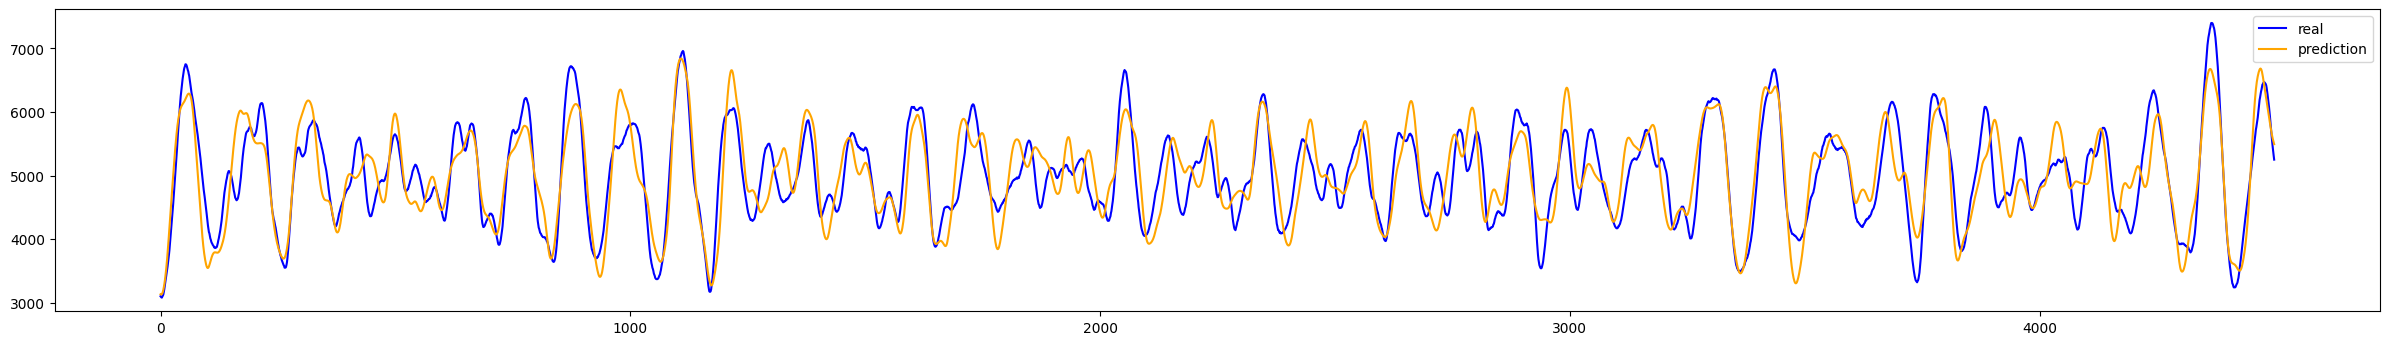

In [84]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force1500_步长40_混合注意力.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')

In [85]:
# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3470:,:], 4, 539)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [87]:
train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 4500, 7500, 12000)
train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4

In [88]:
N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 3000 samples, validate on 4500 samples
Epoch 1/1000
 - 1s - loss: 0.0757 - val_loss: 0.1190
Epoch 2/1000
 - 1s - loss: 0.0511 - val_loss: 0.1320
Epoch 3/1000
 - 1s - loss: 0.0391 - val_loss: 0.1284
Epoch 4/1000
 - 1s - loss: 0.0382 - val_loss: 0.1234
Epoch 5/1000
 - 1s - loss: 0.0371 - val_loss: 0.1270
Epoch 6/1000
 - 1s - loss: 0.0369 - val_loss: 0.1258
Epoch 7/1000
 - 1s - loss: 0.0369 - val_loss: 0.1260
Epoch 8/1000
 - 1s - loss: 0.0369 - val_loss: 0.1257
Epoch 9/1000
 - 1s - loss: 0.0369 - val_loss: 0.1257
Epoch 10/1000
 - 1s - loss: 0.0369 - val_loss: 0.1256
Epoch 11/1000
 - 1s - loss: 0.0370 - val_loss: 0.1256
Epoch 12/1000
 - 1s - loss: 0.0370 - val_loss: 0.1255
Epoch 13/1000
 - 1s - loss: 0.0370 - val_loss: 0.1255
Epoch 14/1000
 - 1s - loss: 0.0369 - val_loss: 0.1255
Epoch 15/1000
 - 1s - loss: 0.0369 - val_loss: 0.1254
Epoch 16/1000
 - 1s - loss: 0.0369 - val_loss: 0.1254
Epoch 17/1000
 - 1s - loss: 0.0369 - val_loss: 0.1254
Epoch 18/1000
 - 1s - loss: 0.0369 - val_lo

 - 1s - loss: 0.0339 - val_loss: 0.1237
Epoch 152/1000
 - 1s - loss: 0.0339 - val_loss: 0.1237
Epoch 153/1000
 - 1s - loss: 0.0339 - val_loss: 0.1237
Epoch 154/1000
 - 1s - loss: 0.0339 - val_loss: 0.1237
Epoch 155/1000
 - 1s - loss: 0.0339 - val_loss: 0.1237
Epoch 156/1000
 - 1s - loss: 0.0339 - val_loss: 0.1238
Epoch 157/1000
 - 1s - loss: 0.0339 - val_loss: 0.1238
Epoch 158/1000
 - 1s - loss: 0.0339 - val_loss: 0.1238
Epoch 159/1000
 - 1s - loss: 0.0339 - val_loss: 0.1238
Epoch 160/1000
 - 1s - loss: 0.0339 - val_loss: 0.1238
Epoch 161/1000
 - 1s - loss: 0.0339 - val_loss: 0.1238
Epoch 162/1000
 - 1s - loss: 0.0339 - val_loss: 0.1239
Epoch 163/1000
 - 1s - loss: 0.0339 - val_loss: 0.1239
Epoch 164/1000
 - 1s - loss: 0.0339 - val_loss: 0.1239
Epoch 165/1000
 - 1s - loss: 0.0339 - val_loss: 0.1239
Epoch 166/1000
 - 1s - loss: 0.0339 - val_loss: 0.1239
Epoch 167/1000
 - 1s - loss: 0.0339 - val_loss: 0.1239
Epoch 168/1000
 - 1s - loss: 0.0339 - val_loss: 0.1239
Epoch 169/1000
 - 1s - lo

 - 1s - loss: 0.0322 - val_loss: 0.1274
Epoch 301/1000
 - 1s - loss: 0.0322 - val_loss: 0.1274
Epoch 302/1000
 - 1s - loss: 0.0322 - val_loss: 0.1274
Epoch 303/1000
 - 1s - loss: 0.0322 - val_loss: 0.1274
Epoch 304/1000
 - 1s - loss: 0.0322 - val_loss: 0.1274
Epoch 305/1000
 - 1s - loss: 0.0322 - val_loss: 0.1275
Epoch 306/1000
 - 1s - loss: 0.0322 - val_loss: 0.1275
Epoch 307/1000
 - 1s - loss: 0.0322 - val_loss: 0.1275
Epoch 308/1000
 - 1s - loss: 0.0322 - val_loss: 0.1275
Epoch 309/1000
 - 1s - loss: 0.0321 - val_loss: 0.1275
Epoch 310/1000
 - 1s - loss: 0.0321 - val_loss: 0.1276
Epoch 311/1000
 - 1s - loss: 0.0321 - val_loss: 0.1276
Epoch 312/1000
 - 1s - loss: 0.0321 - val_loss: 0.1276
Epoch 313/1000
 - 1s - loss: 0.0321 - val_loss: 0.1276
Epoch 314/1000
 - 1s - loss: 0.0321 - val_loss: 0.1276
Epoch 315/1000
 - 1s - loss: 0.0321 - val_loss: 0.1277
Epoch 316/1000
 - 1s - loss: 0.0321 - val_loss: 0.1277
Epoch 317/1000
 - 1s - loss: 0.0321 - val_loss: 0.1277
Epoch 318/1000
 - 1s - lo

 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 450/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 451/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 452/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 453/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 454/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 455/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 456/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 457/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 458/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 459/1000
 - 1s - loss: 0.0306 - val_loss: 0.1292
Epoch 460/1000
 - 1s - loss: 0.0306 - val_loss: 0.1293
Epoch 461/1000
 - 1s - loss: 0.0306 - val_loss: 0.1293
Epoch 462/1000
 - 1s - loss: 0.0306 - val_loss: 0.1293
Epoch 463/1000
 - 1s - loss: 0.0306 - val_loss: 0.1293
Epoch 464/1000
 - 1s - loss: 0.0306 - val_loss: 0.1293
Epoch 465/1000
 - 1s - loss: 0.0306 - val_loss: 0.1293
Epoch 466/1000
 - 1s - loss: 0.0306 - val_loss: 0.1293
Epoch 467/1000
 - 1s - lo

 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 599/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 600/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 601/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 602/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 603/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 604/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 605/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 606/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 607/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 608/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 609/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 610/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 611/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 612/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 613/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 614/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 615/1000
 - 1s - loss: 0.0303 - val_loss: 0.1298
Epoch 616/1000
 - 1s - lo

 - 1s - loss: 0.0301 - val_loss: 0.1299
Epoch 748/1000
 - 1s - loss: 0.0301 - val_loss: 0.1300
Epoch 749/1000
 - 1s - loss: 0.0301 - val_loss: 0.1299
Epoch 750/1000
 - 1s - loss: 0.0301 - val_loss: 0.1300
Epoch 751/1000
 - 1s - loss: 0.0301 - val_loss: 0.1299
Epoch 752/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 753/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 754/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 755/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 756/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 757/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 758/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 759/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 760/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 761/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 762/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 763/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 764/1000
 - 1s - loss: 0.0300 - val_loss: 0.1300
Epoch 765/1000
 - 1s - lo

 - 1s - loss: 0.0288 - val_loss: 0.1304
Epoch 897/1000
 - 1s - loss: 0.0288 - val_loss: 0.1304
Epoch 898/1000
 - 1s - loss: 0.0288 - val_loss: 0.1304
Epoch 899/1000
 - 1s - loss: 0.0288 - val_loss: 0.1304
Epoch 900/1000
 - 1s - loss: 0.0288 - val_loss: 0.1304
Epoch 901/1000
 - 1s - loss: 0.0288 - val_loss: 0.1304
Epoch 902/1000
 - 1s - loss: 0.0288 - val_loss: 0.1304
Epoch 903/1000
 - 1s - loss: 0.0288 - val_loss: 0.1304
Epoch 904/1000
 - 1s - loss: 0.0287 - val_loss: 0.1304
Epoch 905/1000
 - 1s - loss: 0.0287 - val_loss: 0.1304
Epoch 906/1000
 - 1s - loss: 0.0287 - val_loss: 0.1305
Epoch 907/1000
 - 1s - loss: 0.0287 - val_loss: 0.1305
Epoch 908/1000
 - 1s - loss: 0.0287 - val_loss: 0.1304
Epoch 909/1000
 - 1s - loss: 0.0287 - val_loss: 0.1305
Epoch 910/1000
 - 1s - loss: 0.0287 - val_loss: 0.1304
Epoch 911/1000
 - 1s - loss: 0.0287 - val_loss: 0.1305
Epoch 912/1000
 - 1s - loss: 0.0287 - val_loss: 0.1303
Epoch 913/1000
 - 1s - loss: 0.0287 - val_loss: 0.1304
Epoch 914/1000
 - 1s - lo

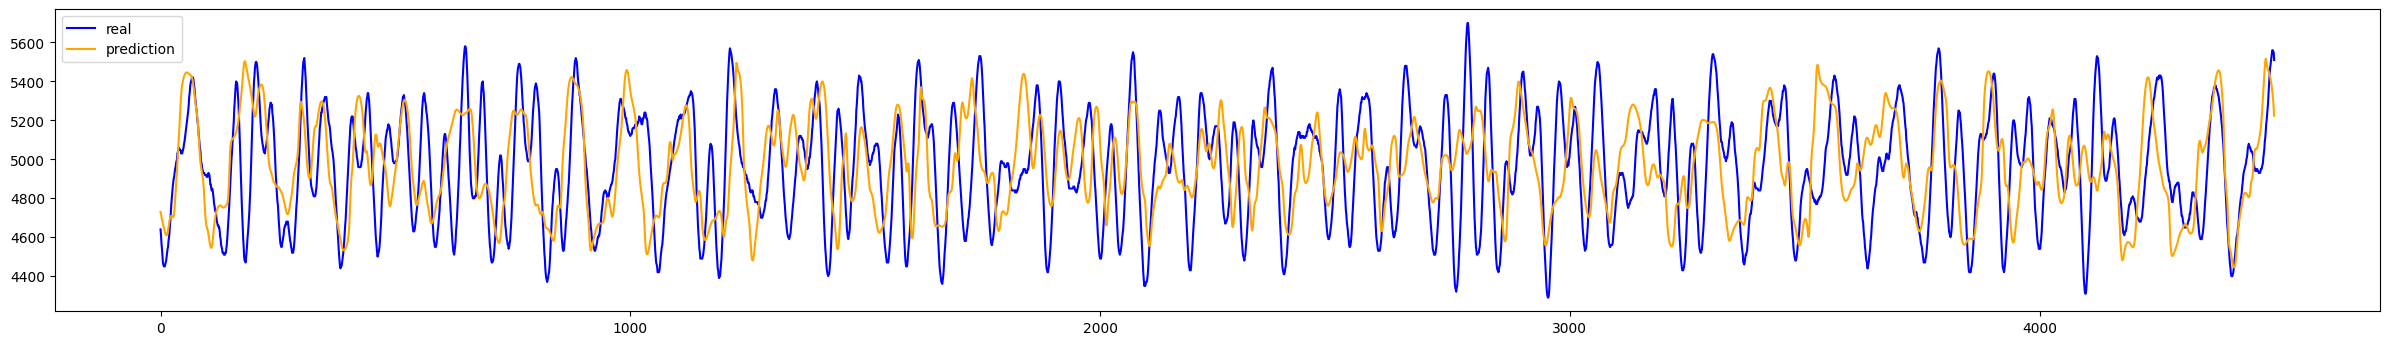

In [89]:
fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force2500_步长40_混合注意力.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')

In [90]:
RNSE(valid50_y4_Force1,N_pre50_Y4_Force1)
Acc(valid50_y4_Force1,N_pre50_Y4_Force1)

RMSE(sklearn): 0.1416703307717016
Acc: 0.9761677266986396


In [91]:
RNSE(valid50_y4_Force2,N_pre50_Y4_Force2)
Acc(valid50_y4_Force2,N_pre50_Y4_Force2)

RMSE(sklearn): 0.3628365275830676
Acc: 0.8232948910802927
